<a href="https://colab.research.google.com/github/diegoray06/test/blob/main/Data_Science_112_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
from pandas_datareader import data as pdr
import datetime

###########################################
# 1️⃣  Pull Risk-Free Rate (10Y Treasury)
###########################################

def get_risk_free_rate():
    start = datetime.datetime.today() - datetime.timedelta(days=30)
    end = datetime.datetime.today()

    # DGS10 = 10-Year Treasury Constant Maturity Rate
    rate_data = pdr.DataReader("DGS10", "fred", start, end)
    latest_rate = rate_data.dropna().iloc[-1][0] / 100
    return latest_rate

r = get_risk_free_rate()


###########################################
# 2️⃣ Black-Scholes Functions
###########################################

def black_scholes_price(S, K, T, r, sigma, option_type):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)


def implied_volatility(price, S, K, T, r, option_type):
    try:
        return brentq(lambda sigma: black_scholes_price(S, K, T, r, sigma, option_type) - price,
                      1e-6, 5)
    except:
        return np.nan


def greeks(S, K, T, r, sigma, option_type):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    delta = norm.cdf(d1) if option_type == "call" else norm.cdf(d1) - 1
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T)
    theta = (-S * norm.pdf(d1) * sigma / (2*np.sqrt(T))
             - r*K*np.exp(-r*T)*norm.cdf(d2 if option_type=="call" else -d2))
    rho = K*T*np.exp(-r*T)*(norm.cdf(d2) if option_type=="call" else -norm.cdf(-d2))

    return delta, gamma, vega, theta, rho


###########################################
# 3️⃣ Pull Option Chain From Yahoo
###########################################

ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# Underlying price
S = ticker.history(period="1d")["Close"].iloc[-1]

# Get all expirations
expirations = ticker.options

all_data = []

for exp in expirations:
    chain = ticker.option_chain(exp)

    for option_type, df in zip(["call", "put"], [chain.calls, chain.puts]):
        df = df.copy()

        df["option_type"] = option_type
        df["expiration"] = exp

        # Time to maturity (years)
        T = (pd.to_datetime(exp) - pd.Timestamp.today()).days / 365
        df["T"] = T

        # Use mid price
        df["mid_price"] = (df["bid"] + df["ask"]) / 2

        # Compute implied vol if needed
        df["calc_iv"] = df.apply(
            lambda row: implied_volatility(
                row["mid_price"], S, row["strike"], T, r, option_type
            ),
            axis=1
        )

        # Use Yahoo IV if available, else calculated
        df["sigma"] = df["impliedVolatility"].fillna(df["calc_iv"])

        # Compute Greeks
        df[["delta", "gamma", "vega", "theta", "rho"]] = df.apply(
            lambda row: pd.Series(
                greeks(S, row["strike"], T, r, row["sigma"], option_type)
            ),
            axis=1
        )

        all_data.append(df)

options_df = pd.concat(all_data)

###########################################
# 4️⃣ Final Dataset
###########################################

dataset = options_df[[
    "contractSymbol",
    "option_type",
    "expiration",
    "strike",
    "mid_price",
    "volume",
    "openInterest",
    "sigma",
    "delta",
    "gamma",
    "vega",
    "theta",
    "rho"
]]

print(dataset)

/tmp/ipykernel_181/809975093.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  latest_rate = rate_data.dropna().iloc[-1][0] / 100
/tmp/ipykernel_181/809975093.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
/tmp/ipykernel_181/809975093.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
/tmp/ipykernel_181/809975093.py:52: RuntimeWarning: invalid value encountered in scalar divide
  gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
/tmp/ipykernel_181/809975093.py:54: RuntimeWarning: invalid value encountered in scalar divide
  theta = (-S * norm.pdf(d1) * sigma / (2*np.sqrt(T))
/tmp/ipykernel_181/809975093.py:30: RuntimeWarning: divide by z

         contractSymbol option_type  expiration  strike  mid_price  volume  \
0   AAPL260304C00210000        call  2026-03-04   210.0     53.675     NaN   
1   AAPL260304C00215000        call  2026-03-04   215.0     48.450     NaN   
2   AAPL260304C00220000        call  2026-03-04   220.0     43.450     1.0   
3   AAPL260304C00225000        call  2026-03-04   225.0     38.450     1.0   
4   AAPL260304C00230000        call  2026-03-04   230.0     33.450     1.0   
..                  ...         ...         ...     ...        ...     ...   
48  AAPL281215P00370000         put  2028-12-15   370.0    108.750    10.0   
49  AAPL281215P00380000         put  2028-12-15   380.0    117.750     2.0   
50  AAPL281215P00390000         put  2028-12-15   390.0    127.000     NaN   
51  AAPL281215P00400000         put  2028-12-15   400.0    136.400     NaN   
52  AAPL281215P00520000         put  2028-12-15   520.0    256.500     1.0   

    openInterest     sigma     delta     gamma        vega     

In [ ]:
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

# ── 1. Fetch S&P 500 tickers ──────────────────────────────────────────────────
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
tables = pd.read_html(response.text)
sp500 = tables[0]
tickers = sp500["Symbol"].tolist()
tickers = [t.replace(".", "-") for t in tickers]  # BRK.B → BRK-B

# Optionally save / reload
pd.Series(tickers).to_csv("sp500_tickers.csv", index=False)
# FIX 1: Use header=0 so the "0" column header isn't read as a ticker
tickers = pd.read_csv("sp500_tickers.csv", header=0).iloc[:, 0].tolist()

print(f"Loaded {len(tickers)} tickers")

# ── 2. Feature engineering ────────────────────────────────────────────────────
def build_features(data):
    data = data.copy()
    data["log_ret"]  = np.log(data["Close"] / data["Close"].shift(1))
    data["ret_5"]    = data["Close"].pct_change(5)
    data["ret_20"]   = data["Close"].pct_change(20)
    data["ret_60"]   = data["Close"].pct_change(60)
    data["vol_20"]   = data["log_ret"].rolling(20).std()
    data["vol_60"]   = data["log_ret"].rolling(60).std()
    data["target"]   = data["Close"].shift(-30) / data["Close"] - 1
    return data.dropna()

# ── 3. Train ML model per stock ───────────────────────────────────────────────
def train_model(data):
    features = ["ret_5", "ret_20", "ret_60", "vol_20", "vol_60"]
    X = data[features]
    y = data["target"]
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ])
    model.fit(X, y)
    predicted_return = model.predict(X.iloc[-1:])[0]
    return predicted_return, data["vol_20"].iloc[-1]

# ── 4. Black-Scholes probability ITM ─────────────────────────────────────────
def itm_probability(S, K, T, r, sigma, option_type):
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d2) if option_type == "call" else norm.cdf(-d2)

# ── 5. Screen the S&P 500 ─────────────────────────────────────────────────────
results   = []
risk_free = 0.04
T         = 30 / 365

for ticker in tickers:
    try:
        data = yf.download(ticker, period="5y", progress=False)

        # FIX 2: keep only stocks with ENOUGH history (was `> 200`, should be `< 200`)
        if len(data) < 200:
            continue

        data = build_features(data)
        predicted_return, sigma = train_model(data)

        S0          = float(data["Close"].iloc[-1])
        expected_ST = S0 * (1 + predicted_return)

        tkr         = yf.Ticker(ticker)
        expirations = tkr.options
        if len(expirations) == 0:
            continue

        exp   = expirations[0]
        chain = tkr.option_chain(exp)

        for option_type, df in zip(["call", "put"], [chain.calls, chain.puts]):
            df = df[np.abs(df["strike"] - S0) / S0 < 0.1].copy()

            for _, row in df.iterrows():
                K       = row["strike"]
                premium = (row["bid"] + row["ask"]) / 2

                if premium <= 0:
                    continue

                prob_itm = itm_probability(S0, K, T, risk_free, sigma, option_type)
                payoff   = (max(expected_ST - K, 0) if option_type == "call"
                            else max(K - expected_ST, 0))
                expected_profit = prob_itm * payoff - premium

                results.append({
                    "Ticker":            ticker,
                    "Type":              option_type,
                    "Expiration":        exp,
                    "Current_Price":     round(S0, 2),
                    "Predicted_Price":   round(expected_ST, 2),
                    "Predicted_Return":  round(predicted_return, 4),
                    "Strike":            K,
                    "Premium":           round(premium, 4),
                    "Prob_ITM":          round(prob_itm, 4),
                    "Expected_Profit":   round(expected_profit, 4),
                })

    except Exception as e:
        print(f"Skipping {ticker}: {e}")
        continue

# ── 6. Rank & display ─────────────────────────────────────────────────────────
if results:
    results_df = pd.DataFrame(results)
    top_opportunities = results_df.sort_values("Expected_Profit", ascending=False).head(25)
    print("\nTop 25 Option Opportunities:\n")
    print(top_opportunities.to_string(index=False))
    top_opportunities.to_csv("top_options.csv", index=False)
    print("\nSaved to top_options.csv")
else:
    print("No results found — check data download / filter settings.")

Loaded 503 tickers

Top 25 Option Opportunities:

Ticker Type Expiration  Current_Price  Predicted_Price  Predicted_Return  Strike  Premium  Prob_ITM  Expected_Profit
   BLK call 2026-03-06        1163.17          1112.80           -0.0433 1050.00    17.10    1.0000          45.6961
   BLK call 2026-03-06        1163.17          1112.80           -0.0433 1055.00    14.10    1.0000          43.6961
   BLK call 2026-03-06        1163.17          1112.80           -0.0433 1060.00    11.00    1.0000          41.7961
   CEG call 2026-03-06         307.71           365.84            0.1889  282.50    42.60    1.0000          40.7419
   CEG call 2026-03-06         307.71           365.84            0.1889  280.00    45.15    1.0000          40.6919
  SNDK call 2026-03-06         413.62           605.28            0.4634  375.00   189.65    1.0000          40.6331
   CEG call 2026-03-06         307.71           365.84            0.1889  285.00    40.35    1.0000          40.4919
   CEG call 20

In [ ]:
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import norm
import datetime
import warnings
warnings.filterwarnings("ignore")

# ── 1. Fetch S&P 500 tickers ──────────────────────────────────────────────────
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
tables = pd.read_html(response.text)
sp500 = tables[0]
tickers = sp500["Symbol"].tolist()
tickers = [t.replace(".", "-") for t in tickers]  # BRK.B → BRK-B

pd.Series(tickers).to_csv("sp500_tickers.csv", index=False)
tickers = pd.read_csv("sp500_tickers.csv", header=0).iloc[:, 0].tolist()
print(f"Loaded {len(tickers)} tickers")

# ── 2. Feature engineering ────────────────────────────────────────────────────
def build_features(data):
    data = data.copy()
    data["log_ret"] = np.log(data["Close"] / data["Close"].shift(1))
    data["ret_5"]   = data["Close"].pct_change(5)
    data["ret_20"]  = data["Close"].pct_change(20)
    data["ret_60"]  = data["Close"].pct_change(60)
    data["vol_20"]  = data["log_ret"].rolling(20).std()
    data["vol_60"]  = data["log_ret"].rolling(60).std()
    data["target"]  = data["Close"].shift(-30) / data["Close"] - 1
    return data.dropna()

# ── 3. Train ML model per stock ───────────────────────────────────────────────
def train_model(data):
    features = ["ret_5", "ret_20", "ret_60", "vol_20", "vol_60"]
    X = data[features]
    y = data["target"]
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ])
    model.fit(X, y)
    predicted_return = model.predict(X.iloc[-1:])[0]
    return predicted_return, data["vol_20"].iloc[-1]

# ── 4. Black-Scholes probability ITM ─────────────────────────────────────────
def itm_probability(S, K, T, r, sigma, option_type):
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d2) if option_type == "call" else norm.cdf(-d2)

# ── 5. Screen the S&P 500 ─────────────────────────────────────────────────────
results   = []
risk_free = 0.04
today     = datetime.date.today()

for ticker in tickers:
    try:
        data = yf.download(ticker, period="5y", progress=False)

        if len(data) < 200:
            continue

        data = build_features(data)
        predicted_return_30d, sigma = train_model(data)

        tkr = yf.Ticker(ticker)

        # FIX 1: use fast_info for the most current market price
        S0 = tkr.fast_info["last_price"]

        expirations = tkr.options
        if len(expirations) == 0:
            continue

        # Pick expiration closest to 30 days out
        target_date = today + datetime.timedelta(days=30)
        exp = min(expirations, key=lambda e: abs(datetime.date.fromisoformat(e) - target_date))
        chain = tkr.option_chain(exp)

        # FIX 2: compute T dynamically from today to actual expiration date
        exp_date    = datetime.date.fromisoformat(exp)
        days_to_exp = max((exp_date - today).days, 1)
        T           = days_to_exp / 365

        # Scale the 30-day predicted return proportionally to the actual option window
        # e.g. a 5-day option should only capture 5/30 of the predicted 30-day move
        scaled_return = predicted_return_30d * (days_to_exp / 30)
        expected_ST   = S0 * (1 + scaled_return)

        for option_type, df in zip(["call", "put"], [chain.calls, chain.puts]):
            df = df[np.abs(df["strike"] - S0) / S0 < 0.1].copy()

            for _, row in df.iterrows():
                K       = row["strike"]
                premium = (row["bid"] + row["ask"]) / 2

                if premium <= 0:
                    continue

                prob_itm        = itm_probability(S0, K, T, risk_free, sigma, option_type)
                payoff          = (max(expected_ST - K, 0) if option_type == "call"
                                   else max(K - expected_ST, 0))
                expected_profit = prob_itm * payoff - premium

                results.append({
                    "Ticker":           ticker,
                    "Type":             option_type,
                    "Expiration":       exp,
                    "Days_To_Exp":      days_to_exp,
                    "Current_Price":    round(S0, 2),
                    "Predicted_Price":  round(expected_ST, 2),
                    "Predicted_Return": round(predicted_return_30d, 4),
                    "Scaled_Return":    round(scaled_return, 4),
                    "Strike":           K,
                    "Premium":          round(premium, 4),
                    "Prob_ITM":         round(prob_itm, 4),
                    "Expected_Profit":  round(expected_profit, 4),
                })

    except Exception as e:
        print(f"Skipping {ticker}: {e}")
        continue

# ── 6. Rank & display ─────────────────────────────────────────────────────────
if results:
    results_df        = pd.DataFrame(results)
    top_opportunities = results_df.sort_values("Expected_Profit", ascending=False).head(25)
    print("\nTop 25 Option Opportunities:\n")
    print(top_opportunities.to_string(index=False))
    top_opportunities.to_csv("top_options.csv", index=False)
    print("\nSaved to top_options.csv")
else:
    print("No results found — check data download / filter settings.")

Loaded 503 tickers

Top 25 Option Opportunities:

Ticker Type Expiration  Days_To_Exp  Current_Price  Predicted_Price  Predicted_Return  Scaled_Return  Strike  Premium  Prob_ITM  Expected_Profit
  BKNG  put 2026-04-02           29        4153.87          3619.09           -0.1332        -0.1287  4220.0   221.60    1.0000         379.3005
  BKNG  put 2026-04-02           29        4153.87          3619.09           -0.1332        -0.1287  4210.0   216.50    0.9997         374.2467
  BKNG  put 2026-04-02           29        4153.87          3619.09           -0.1332        -0.1287  4180.0   201.65    0.8521         276.2955
  SNDK call 2026-04-02           29         565.41           818.68            0.4634         0.4479   510.0    94.05    1.0000         214.6262
  SNDK call 2026-04-02           29         565.41           818.68            0.4634         0.4479   520.0    87.00    1.0000         211.6749
  SNDK call 2026-04-02           29         565.41           818.68            0

In [ ]:
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import norm
import datetime
import traceback
import warnings
warnings.filterwarnings("ignore")

# ── 1. Fetch S&P 500 tickers ──────────────────────────────────────────────────
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
tables = pd.read_html(response.text)
tickers = tables[0]["Symbol"].tolist()
tickers = [t.replace(".", "-") for t in tickers]

pd.Series(tickers).to_csv("sp500_tickers.csv", index=False)
tickers = pd.read_csv("sp500_tickers.csv", header=0).iloc[:, 0].tolist()
print(f"Loaded {len(tickers)} tickers")

# ── 2. yfinance MultiIndex fix ────────────────────────────────────────────────
def flatten_yf(raw):
    """
    Recent yfinance versions return MultiIndex columns like ("Close", "AAPL").
    Flatten to simple names: "Close", "Open", etc.
    """
    if isinstance(raw.columns, pd.MultiIndex):
        raw = raw.copy()
        raw.columns = raw.columns.get_level_values(0)
    # Remove any duplicate columns (can happen with MultiIndex flatten)
    raw = raw.loc[:, ~raw.columns.duplicated()]
    return raw

# ── 3. Horizon buckets ────────────────────────────────────────────────────────
HORIZONS = {
    "1w":  {"days": 7,  "vol_windows": [5,  10]},
    "2w":  {"days": 14, "vol_windows": [10, 20]},
    "1m":  {"days": 30, "vol_windows": [20, 60]},
    "2m":  {"days": 60, "vol_windows": [30, 60]},
}

def horizon_for_dte(dte):
    return min(HORIZONS, key=lambda h: abs(HORIZONS[h]["days"] - dte))

# ── 4. Feature engineering (horizon-aware) ───────────────────────────────────
def build_features(data, horizon_days, vol_windows):
    data = data.copy()
    close = data["Close"].squeeze()  # ensure Series even if single-col DataFrame
    data["log_ret"] = np.log(close / close.shift(1))
    data["ret_5"]   = close.pct_change(5)
    data["ret_20"]  = close.pct_change(20)
    data["ret_60"]  = close.pct_change(60)

    feature_cols = ["ret_5", "ret_20", "ret_60"]
    for w in vol_windows:
        col = f"vol_{w}"
        data[col] = data["log_ret"].rolling(w).std()
        feature_cols.append(col)

    data["target"] = close.shift(-horizon_days) / close - 1
    data = data.dropna(subset=feature_cols + ["target"])
    return data, feature_cols

# ── 5. Train horizon-specific model ──────────────────────────────────────────
def train_model(data, feature_cols):
    X = data[feature_cols]
    y = data["target"]
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ])
    model.fit(X, y)
    predicted_return = model.predict(X.iloc[-1:])[0]
    # Use the shorter vol window as annualised realised sigma for Black-Scholes
    sigma = float(data[feature_cols[-2]].iloc[-1]) * np.sqrt(252)
    return predicted_return, sigma

# ── 6. Black-Scholes probability ITM ─────────────────────────────────────────
def itm_probability(S, K, T, r, sigma, option_type):
    if sigma <= 0 or T <= 0:
        return 0.0
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d2) if option_type == "call" else norm.cdf(-d2)

# ── 7. Screen the S&P 500 ─────────────────────────────────────────────────────
results   = []
risk_free = 0.04
today     = datetime.date.today()

for ticker in tickers:
    try:
        raw = yf.download(ticker, period="5y", progress=False)

        # FIX: flatten MultiIndex columns FIRST before any other operations
        raw = flatten_yf(raw)

        if len(raw) < 200:
            continue

        tkr = yf.Ticker(ticker)
        S0  = tkr.fast_info["last_price"]

        expirations = tkr.options
        if not expirations:
            continue

        # Pick expiration closest to 30 days out
        target_date = today + datetime.timedelta(days=30)
        exp = min(expirations, key=lambda e: abs(datetime.date.fromisoformat(e) - target_date))

        exp_date    = datetime.date.fromisoformat(exp)
        days_to_exp = max((exp_date - today).days, 1)
        T           = days_to_exp / 365

        # Select horizon bucket matching actual DTE and train accordingly
        bucket_key  = horizon_for_dte(days_to_exp)
        bucket      = HORIZONS[bucket_key]

        data, feature_cols = build_features(raw, bucket["days"], bucket["vol_windows"])
        if len(data) < 100:
            continue

        predicted_return, sigma = train_model(data, feature_cols)
        expected_ST = S0 * (1 + predicted_return)

        chain = tkr.option_chain(exp)

        for option_type, df in zip(["call", "put"], [chain.calls, chain.puts]):
            df = df[np.abs(df["strike"] - S0) / S0 < 0.1].copy()

            for _, row in df.iterrows():
                K       = row["strike"]
                premium = (row["bid"] + row["ask"]) / 2
                if premium <= 0:
                    continue

                prob_itm        = itm_probability(S0, K, T, risk_free, sigma, option_type)
                payoff          = (max(expected_ST - K, 0) if option_type == "call"
                                   else max(K - expected_ST, 0))
                expected_profit = prob_itm * payoff - premium

                results.append({
                    "Ticker":           ticker,
                    "Type":             option_type,
                    "Expiration":       exp,
                    "Days_To_Exp":      days_to_exp,
                    "Horizon_Bucket":   bucket_key,
                    "Current_Price":    round(S0, 2),
                    "Predicted_Price":  round(expected_ST, 2),
                    "Predicted_Return": round(predicted_return, 4),
                    "Strike":           K,
                    "Premium":          round(premium, 4),
                    "Prob_ITM":         round(prob_itm, 4),
                    "Expected_Profit":  round(expected_profit, 4),
                })

    except Exception as e:
        # Print the actual error type and message, not just the exception value
        print(f"Skipping {ticker}: {type(e).__name__}: {e}")
        continue

# ── 8. Rank & display ─────────────────────────────────────────────────────────
if results:
    results_df        = pd.DataFrame(results)
    top_opportunities = results_df.sort_values("Expected_Profit", ascending=False).head(25)
    print("\nTop 25 Option Opportunities:\n")
    print(top_opportunities.to_string(index=False))
    top_opportunities.to_csv("top_options.csv", index=False)
    print("\nSaved to top_options.csv")
else:
    print("No results found — check data download / filter settings.")

Loaded 503 tickers

Top 25 Option Opportunities:

Ticker Type Expiration  Days_To_Exp Horizon_Bucket  Current_Price  Predicted_Price  Predicted_Return  Strike  Premium  Prob_ITM  Expected_Profit
   MCK call 2026-04-02           29             1m         995.69          1167.16            0.1722   920.0    86.75    0.9964         159.5174
  BKNG  put 2026-04-02           29             1m        4153.87          3600.65           -0.1332  4220.0   221.60    0.6148         159.1618
   MCK call 2026-04-02           29             1m         995.69          1167.16            0.1722   940.0    70.35    0.9761         151.3902
  BKNG  put 2026-04-02           29             1m        4153.87          3600.65           -0.1332  4210.0   216.50    0.5954         146.2793
   MCK call 2026-04-02           29             1m         995.69          1167.16            0.1722   950.0    63.30    0.9487         142.7168
   GEV call 2026-04-02           29             1m         842.00          1055.

In [ ]:
top_opportunities = results_df.sort_values("Expected_Profit", ascending=False).head(30)
top_opportunities

,Ticker,Type,Expiration,Days_To_Exp,Horizon_Bucket,Current_Price,Predicted_Price,Predicted_Return,Strike,Premium,Prob_ITM,Expected_Profit
4740,MCK,call,2026-04-02,29,1m,995.69,1167.16,0.1722,920.0,86.750,0.9964,159.5174
1122,BKNG,put,2026-04-02,29,1m,4153.87,3600.65,-0.1332,4220.0,221.600,0.6148,159.1618
4741,MCK,call,2026-04-02,29,1m,995.69,1167.16,0.1722,940.0,70.350,0.9761,151.3902
1121,BKNG,put,2026-04-02,29,1m,4153.87,3600.65,-0.1332,4210.0,216.500,0.5954,146.2793
4742,MCK,call,2026-04-02,29,1m,995.69,1167.16,0.1722,950.0,63.300,0.9487,142.7168
3323,GEV,call,2026-04-02,29,1m,842.00,1055.15,0.2531,760.0,104.950,0.8039,132.3263
4743,MCK,call,2026-04-02,29,1m,995.69,1167.16,0.1722,960.0,55.250,0.9012,131.4373
3324,GEV,call,2026-04-02,29,1m,842.00,1055.15,0.2531,770.0,96.500,0.7712,123.3949
4744,MCK,call,2026-04-02,29,1m,995.69,1167.16,0.1722,970.0,49.550,0.8284,113.7773
3325,GEV,call,2026-04-02,29,1m,842.00,1055.15,0.2531,780.0,90.250,0.7360,112.2615


In [ ]:
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import norm
import datetime
import warnings
warnings.filterwarnings("ignore")

# ── 1. Fetch S&P 500 tickers ──────────────────────────────────────────────────
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
tables = pd.read_html(response.text)
tickers = tables[0]["Symbol"].tolist()
tickers = [t.replace(".", "-") for t in tickers]

pd.Series(tickers).to_csv("sp500_tickers.csv", index=False)
tickers = pd.read_csv("sp500_tickers.csv", header=0).iloc[:, 0].tolist()
print(f"Loaded {len(tickers)} tickers")

# ── 2. yfinance MultiIndex fix ────────────────────────────────────────────────
def flatten_yf(raw):
    if isinstance(raw.columns, pd.MultiIndex):
        raw = raw.copy()
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.loc[:, ~raw.columns.duplicated()]
    return raw

# ── 3. Horizon buckets ────────────────────────────────────────────────────────
HORIZONS = {
    "1w":  {"days": 7,  "vol_windows": [5,  10]},
    "2w":  {"days": 14, "vol_windows": [10, 20]},
    "1m":  {"days": 30, "vol_windows": [20, 60]},
    "2m":  {"days": 60, "vol_windows": [30, 60]},
}

def horizon_for_dte(dte):
    return min(HORIZONS, key=lambda h: abs(HORIZONS[h]["days"] - dte))

# ── 4. Feature engineering (horizon-aware) ───────────────────────────────────
def build_features(data, horizon_days, vol_windows):
    data = data.copy()
    close = data["Close"].squeeze()
    data["log_ret"] = np.log(close / close.shift(1))
    data["ret_5"]   = close.pct_change(5)
    data["ret_20"]  = close.pct_change(20)
    data["ret_60"]  = close.pct_change(60)

    feature_cols = ["ret_5", "ret_20", "ret_60"]
    for w in vol_windows:
        col = f"vol_{w}"
        data[col] = data["log_ret"].rolling(w).std()
        feature_cols.append(col)

    data["target"] = close.shift(-horizon_days) / close - 1
    data = data.dropna(subset=feature_cols + ["target"])
    return data, feature_cols

# ── 5. Train horizon-specific model ──────────────────────────────────────────
def train_model(data, feature_cols):
    X = data[feature_cols]
    y = data["target"]
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ])
    model.fit(X, y)
    predicted_return = model.predict(X.iloc[-1:])[0]
    sigma = float(data[feature_cols[-2]].iloc[-1]) * np.sqrt(252)
    return predicted_return, sigma

# ── 6. Black-Scholes probability ITM ─────────────────────────────────────────
def itm_probability(S, K, T, r, sigma, option_type):
    if sigma <= 0 or T <= 0:
        return 0.0
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d2) if option_type == "call" else norm.cdf(-d2)

# ── 7. Extrinsic value filter ─────────────────────────────────────────────────
def extrinsic_value(S, K, premium, option_type):
    """
    Intrinsic value is what you'd get if you exercised right now.
    Extrinsic (time) value = premium - intrinsic value.
    This is what you're actually paying for optionality.
    Deep ITM options have very little extrinsic value — you're mostly
    just paying for intrinsic value, which you could get more efficiently
    by buying the stock directly.
    """
    intrinsic = max(S - K, 0) if option_type == "call" else max(K - S, 0)
    return premium - intrinsic

# ── 8. Screen the S&P 500 ─────────────────────────────────────────────────────
results   = []
risk_free = 0.04
today     = datetime.date.today()

# Minimum extrinsic value as % of stock price.
# Filters out deep ITM options where you're mostly paying intrinsic value.
# e.g. 0.005 = at least 0.5% of stock price must be time value.
MIN_EXTRINSIC_PCT = 0.005

# Minimum expected return on premium to be worth considering.
# e.g. 0.10 = must expect at least 10% return on the premium paid.
MIN_EXPECTED_RETURN = 0.10

for ticker in tickers:
    try:
        raw = yf.download(ticker, period="5y", progress=False)
        raw = flatten_yf(raw)

        if len(raw) < 200:
            continue

        tkr = yf.Ticker(ticker)
        S0  = tkr.fast_info["last_price"]

        expirations = tkr.options
        if not expirations:
            continue

        target_date = today + datetime.timedelta(days=30)
        exp = min(expirations, key=lambda e: abs(datetime.date.fromisoformat(e) - target_date))

        exp_date    = datetime.date.fromisoformat(exp)
        days_to_exp = max((exp_date - today).days, 1)
        T           = days_to_exp / 365

        bucket_key  = horizon_for_dte(days_to_exp)
        bucket      = HORIZONS[bucket_key]

        data, feature_cols = build_features(raw, bucket["days"], bucket["vol_windows"])
        if len(data) < 100:
            continue

        predicted_return, sigma = train_model(data, feature_cols)
        expected_ST = S0 * (1 + predicted_return)

        chain = tkr.option_chain(exp)

        for option_type, df in zip(["call", "put"], [chain.calls, chain.puts]):
            df = df[np.abs(df["strike"] - S0) / S0 < 0.1].copy()

            for _, row in df.iterrows():
                K       = row["strike"]
                premium = (row["bid"] + row["ask"]) / 2
                if premium <= 0:
                    continue

                # Filter: require meaningful extrinsic (time) value.
                # Deep ITM options fail this — they're basically stock ownership
                # at a premium with no leverage benefit.
                ext_val = extrinsic_value(S0, K, premium, option_type)
                if ext_val < S0 * MIN_EXTRINSIC_PCT:
                    continue

                prob_itm        = itm_probability(S0, K, T, risk_free, sigma, option_type)
                payoff          = (max(expected_ST - K, 0) if option_type == "call"
                                   else max(K - expected_ST, 0))
                expected_profit = prob_itm * payoff - premium

                # Return on premium: the actual leverage-adjusted metric.
                # This is what separates a good options trade from "just buy the stock".
                expected_rop    = expected_profit / premium

                # Filter: require a minimum expected return on capital
                if expected_rop < MIN_EXPECTED_RETURN:
                    continue

                results.append({
                    "Ticker":           ticker,
                    "Type":             option_type,
                    "Expiration":       exp,
                    "Days_To_Exp":      days_to_exp,
                    "Horizon_Bucket":   bucket_key,
                    "Current_Price":    round(S0, 2),
                    "Predicted_Price":  round(expected_ST, 2),
                    "Predicted_Return": round(predicted_return, 4),
                    "Strike":           K,
                    "Premium":          round(premium, 4),
                    "Extrinsic_Value":  round(ext_val, 4),
                    "Prob_ITM":         round(prob_itm, 4),
                    "Expected_Profit":  round(expected_profit, 4),
                    # Primary ranking metric: return on premium paid
                    "Expected_ROP":     round(expected_rop, 4),
                })

    except Exception as e:
        print(f"Skipping {ticker}: {type(e).__name__}: {e}")
        continue

# ── 9. Rank by return on premium, not raw dollar profit ──────────────────────
if results:
    results_df        = pd.DataFrame(results)
    top_opportunities = results_df.sort_values("Expected_ROP", ascending=False).head(25)
    print("\nTop 25 Option Opportunities (ranked by Return on Premium):\n")
    print(top_opportunities.to_string(index=False))
    top_opportunities.to_csv("top_options.csv", index=False)
    print("\nSaved to top_options.csv")
else:
    print("No results found — check data download / filter settings.")

Loaded 503 tickers

Top 25 Option Opportunities (ranked by Return on Premium):

Ticker Type Expiration  Days_To_Exp Horizon_Bucket  Current_Price  Predicted_Price  Predicted_Return  Strike  Premium  Extrinsic_Value  Prob_ITM  Expected_Profit  Expected_ROP
   GLW call 2026-04-02           29             1m         147.57           230.69            0.5633   137.0   18.025            7.455    0.8242          59.1958        3.2841
   GLW call 2026-04-02           29             1m         147.57           230.69            0.5633   134.0   20.100            6.530    0.8867          65.6335        3.2653
   GLW call 2026-04-02           29             1m         147.57           230.69            0.5633   140.0   15.900            8.330    0.7454          51.6987        3.2515
   GLW call 2026-04-02           29             1m         147.57           230.69            0.5633   138.0   17.450            7.880    0.7997          56.6700        3.2476
   GLW call 2026-04-02           29     

In [ ]:
top_opportunities

,Ticker,Type,Expiration,Days_To_Exp,Horizon_Bucket,Current_Price,Predicted_Price,Predicted_Return,Strike,Premium,Extrinsic_Value,Prob_ITM,Expected_Profit,Expected_ROP
336,GLW,call,2026-04-02,29,1m,147.57,230.69,0.5633,137.0,18.025,7.455,0.8242,59.1958,3.2841
333,GLW,call,2026-04-02,29,1m,147.57,230.69,0.5633,134.0,20.100,6.530,0.8867,65.6335,3.2653
339,GLW,call,2026-04-02,29,1m,147.57,230.69,0.5633,140.0,15.900,8.330,0.7454,51.6987,3.2515
337,GLW,call,2026-04-02,29,1m,147.57,230.69,0.5633,138.0,17.450,7.880,0.7997,56.6700,3.2476
335,GLW,call,2026-04-02,29,1m,147.57,230.69,0.5633,136.0,18.900,7.330,0.8469,61.2964,3.2432
334,GLW,call,2026-04-02,29,1m,147.57,230.69,0.5633,135.0,19.650,7.080,0.8678,63.3864,3.2258
332,GLW,call,2026-04-02,29,1m,147.57,230.69,0.5633,133.0,20.900,6.330,0.9037,67.3832,3.2241
1217,VZ,call,2026-04-02,29,1m,50.87,62.34,0.2254,50.0,1.965,1.095,0.6708,6.3091,3.2107
338,GLW,call,2026-04-02,29,1m,147.57,230.69,0.5633,139.0,17.125,8.555,0.7733,53.7824,3.1406
1218,VZ,call,2026-04-02,29,1m,50.87,62.34,0.2254,51.0,1.385,1.385,0.4969,4.2475,3.0668


In [ ]:
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import norm
import datetime
import warnings
warnings.filterwarnings("ignore")

# ── 1. Fetch S&P 500 tickers ──────────────────────────────────────────────────
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
tables = pd.read_html(response.text)
tickers = tables[0]["Symbol"].tolist()
tickers = [t.replace(".", "-") for t in tickers]

pd.Series(tickers).to_csv("sp500_tickers.csv", index=False)
tickers = pd.read_csv("sp500_tickers.csv", header=0).iloc[:, 0].tolist()
print(f"Loaded {len(tickers)} tickers")

# ── 2. yfinance MultiIndex fix ────────────────────────────────────────────────
def flatten_yf(raw):
    if isinstance(raw.columns, pd.MultiIndex):
        raw = raw.copy()
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.loc[:, ~raw.columns.duplicated()]
    return raw

# ── 3. Horizon buckets ────────────────────────────────────────────────────────
HORIZONS = {
    "1w":  {"days": 7,  "vol_windows": [5,  10]},
    "2w":  {"days": 14, "vol_windows": [10, 20]},
    "1m":  {"days": 30, "vol_windows": [20, 60]},
    "2m":  {"days": 60, "vol_windows": [30, 60]},
}

def horizon_for_dte(dte):
    return min(HORIZONS, key=lambda h: abs(HORIZONS[h]["days"] - dte))

# ── 4. Feature engineering (horizon-aware + mean-reversion aware) ─────────────
def build_features(data, horizon_days, vol_windows):
    data = data.copy()
    close = data["Close"].squeeze()
    data["log_ret"] = np.log(close / close.shift(1))

    # Momentum
    data["ret_5"]  = close.pct_change(5)
    data["ret_20"] = close.pct_change(20)
    data["ret_60"] = close.pct_change(60)
    feature_cols = ["ret_5", "ret_20", "ret_60"]

    # Volatility (horizon-matched windows)
    for w in vol_windows:
        col = f"vol_{w}"
        data[col] = data["log_ret"].rolling(w).std()
        feature_cols.append(col)

    # ── Extension / mean-reversion features ───────────────────────────────────
    # Z-score vs 60-day mean: short-term overextension
    roll60  = close.rolling(60)
    data["z_score_60"]  = (close - roll60.mean()) / roll60.std()

    # Z-score vs 252-day mean: is the stock historically stretched?
    # +2 or +3 means price is far above its yearly average — the model learns
    # this predicts lower forward returns, dampening bull-run extrapolation.
    roll252 = close.rolling(252)
    data["z_score_252"] = (close - roll252.mean()) / roll252.std()

    # Distance from 52-week high: 0.0 = AT the high, -0.20 = 20% below.
    # Captures "how late in the run are we" — near the high after a big rally
    # is a very different setup than near the high after a slow grind.
    data["pct_from_52w_high"] = close / close.rolling(252).max() - 1

    # Distance from 52-week low: symmetric context on the downside
    data["pct_from_52w_low"]  = close / close.rolling(252).min() - 1

    # Vol ratio: short-term vol relative to long-term vol.
    # >> 1 means vol is spiking, often signals a climactic/exhaustion move.
    short_vol_col = f"vol_{vol_windows[0]}"
    long_vol_col  = f"vol_{vol_windows[-1]}"
    data["vol_ratio"] = data[short_vol_col] / data[long_vol_col]

    extension_cols = [
        "z_score_60", "z_score_252",
        "pct_from_52w_high", "pct_from_52w_low",
        "vol_ratio",
    ]
    feature_cols += extension_cols

    data["target"] = close.shift(-horizon_days) / close - 1
    data = data.dropna(subset=feature_cols + ["target"])
    return data, feature_cols

# ── 5. Train horizon-specific model ──────────────────────────────────────────
def train_model(data, feature_cols):
    X = data[feature_cols]
    y = data["target"]
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ])
    model.fit(X, y)
    predicted_return = model.predict(X.iloc[-1:])[0]
    # Annualise the shorter vol window for Black-Scholes
    short_vol_col = [c for c in feature_cols if c.startswith("vol_")][0]
    sigma = float(data[short_vol_col].iloc[-1]) * np.sqrt(252)
    return predicted_return, sigma

# ── 6. Black-Scholes probability ITM ─────────────────────────────────────────
def itm_probability(S, K, T, r, sigma, option_type):
    if sigma <= 0 or T <= 0:
        return 0.0
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d2) if option_type == "call" else norm.cdf(-d2)

# ── 7. Extrinsic value helpers ────────────────────────────────────────────────
def extrinsic_value(S, K, premium, option_type):
    intrinsic = max(S - K, 0) if option_type == "call" else max(K - S, 0)
    return premium - intrinsic

# ── 8. Screen the S&P 500 ─────────────────────────────────────────────────────
results   = []
risk_free = 0.04
today     = datetime.date.today()

MIN_EXTRINSIC_PCT  = 0.005   # at least 0.5% of stock price must be time value
MIN_EXPECTED_RETURN = 0.10   # at least 10% expected return on premium paid

for ticker in tickers:
    try:
        raw = yf.download(ticker, period="10y", progress=False)
        raw = flatten_yf(raw)

        if len(raw) < 252:   # need at least 1 year for 52w features to be valid
            continue

        tkr = yf.Ticker(ticker)
        S0  = tkr.fast_info["last_price"]

        expirations = tkr.options
        if not expirations:
            continue

        target_date = today + datetime.timedelta(days=30)
        exp = min(expirations, key=lambda e: abs(datetime.date.fromisoformat(e) - target_date))

        exp_date    = datetime.date.fromisoformat(exp)
        days_to_exp = max((exp_date - today).days, 1)
        T           = days_to_exp / 365

        bucket_key  = horizon_for_dte(days_to_exp)
        bucket      = HORIZONS[bucket_key]

        data, feature_cols = build_features(raw, bucket["days"], bucket["vol_windows"])
        if len(data) < 100:
            continue

        predicted_return, sigma = train_model(data, feature_cols)
        expected_ST = S0 * (1 + predicted_return)

        chain = tkr.option_chain(exp)

        for option_type, df in zip(["call", "put"], [chain.calls, chain.puts]):
            df = df[np.abs(df["strike"] - S0) / S0 < 0.1].copy()

            for _, row in df.iterrows():
                K       = row["strike"]
                premium = (row["bid"] + row["ask"]) / 2
                if premium <= 0:
                    continue

                ext_val = extrinsic_value(S0, K, premium, option_type)
                if ext_val < S0 * MIN_EXTRINSIC_PCT:
                    continue

                prob_itm        = itm_probability(S0, K, T, risk_free, sigma, option_type)
                payoff          = (max(expected_ST - K, 0) if option_type == "call"
                                   else max(K - expected_ST, 0))
                expected_profit = prob_itm * payoff - premium
                expected_rop    = expected_profit / premium

                if expected_rop < MIN_EXPECTED_RETURN:
                    continue

                results.append({
                    "Ticker":           ticker,
                    "Type":             option_type,
                    "Expiration":       exp,
                    "Days_To_Exp":      days_to_exp,
                    "Horizon_Bucket":   bucket_key,
                    "Current_Price":    round(S0, 2),
                    "Predicted_Price":  round(expected_ST, 2),
                    "Predicted_Return": round(predicted_return, 4),
                    "Strike":           K,
                    "Premium":          round(premium, 4),
                    "Extrinsic_Value":  round(ext_val, 4),
                    "Prob_ITM":         round(prob_itm, 4),
                    "Expected_Profit":  round(expected_profit, 4),
                    "Expected_ROP":     round(expected_rop, 4),
                })

    except Exception as e:
        print(f"Skipping {ticker}: {type(e).__name__}: {e}")
        continue

# ── 9. Rank by return on premium ─────────────────────────────────────────────
if results:
    results_df        = pd.DataFrame(results)
    top_opportunities_rop = results_df.sort_values("Expected_ROP", ascending=False).head(25)
    print("\nTop 25 Option Opportunities (ranked by Return on Premium):\n")
    print(top_opportunities_rop.to_string(index=False))
    top_opportunities.to_csv("top_options.csv", index=False)
    print("\nSaved to top_options.csv")
else:
    print("No results found — check data download / filter settings.")

Loaded 503 tickers

Top 25 Option Opportunities (ranked by Return on Premium):

Ticker Type Expiration  Days_To_Exp Horizon_Bucket  Current_Price  Predicted_Price  Predicted_Return  Strike  Premium  Extrinsic_Value  Prob_ITM  Expected_Profit  Expected_ROP
   GLW call 2026-04-02           29             1m         147.57           233.57            0.5828   137.0   18.025            7.455    0.8242          61.5709        3.4159
   GLW call 2026-04-02           29             1m         147.57           233.57            0.5828   134.0   20.100            6.530    0.8867          68.1886        3.3925
   GLW call 2026-04-02           29             1m         147.57           233.57            0.5828   140.0   15.900            8.330    0.7454          53.8467        3.3866
   GLW call 2026-04-02           29             1m         147.57           233.57            0.5828   138.0   17.450            7.880    0.7997          58.9744        3.3796
   GLW call 2026-04-02           29     

In [ ]:
top_opportunities_profit = results_df.sort_values("Expected_Profit", ascending=False).head(25)
top_opportunities_profit


,Ticker,Type,Expiration,Days_To_Exp,Horizon_Bucket,Current_Price,Predicted_Price,Predicted_Return,Strike,Premium,Extrinsic_Value,Prob_ITM,Expected_Profit,Expected_ROP
159,BKNG,put,2026-04-02,29,1m,4153.87,3530.29,-0.1501,4220.0,221.60,155.4701,0.6148,202.4192,0.9134
158,BKNG,put,2026-04-02,29,1m,4153.87,3530.29,-0.1501,4210.0,216.50,160.3701,0.5954,188.1701,0.8691
823,MCK,call,2026-04-02,29,1m,995.69,1162.02,0.1671,920.0,86.75,11.0600,0.9964,154.3983,1.7798
824,MCK,call,2026-04-02,29,1m,995.69,1162.02,0.1671,940.0,70.35,14.6600,0.9761,146.3751,2.0807
157,BKNG,put,2026-04-02,29,1m,4153.87,3530.29,-0.1501,4180.0,201.65,175.5201,0.5356,146.3147,0.7256
825,MCK,call,2026-04-02,29,1m,995.69,1162.02,0.1671,950.0,63.30,17.6100,0.9487,137.8428,2.1776
611,GEV,call,2026-04-02,29,1m,842.00,1059.05,0.2578,760.0,104.95,22.9500,0.8039,135.4624,1.2907
826,MCK,call,2026-04-02,29,1m,995.69,1162.02,0.1671,960.0,55.25,19.5600,0.9012,126.8074,2.2952
612,GEV,call,2026-04-02,29,1m,842.00,1059.05,0.2578,770.0,96.50,24.5000,0.7712,126.4032,1.3099
613,GEV,call,2026-04-02,29,1m,842.00,1059.05,0.2578,780.0,90.25,28.2500,0.7360,115.1327,1.2757


In [ ]:
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import norm
from scipy.optimize import brentq
from concurrent.futures import ThreadPoolExecutor, as_completed
import datetime
import warnings
warnings.filterwarnings("ignore")

# ── 1. Fetch S&P 500 tickers ──────────────────────────────────────────────────
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
tables = pd.read_html(response.text)
tickers = tables[0]["Symbol"].tolist()
tickers = [t.replace(".", "-") for t in tickers]
print(f"Loaded {len(tickers)} tickers")

# ── 2. Bulk download all price history ───────────────────────────────────────
print("Downloading price history (bulk)...")
raw_all = yf.download(tickers, period="10y", progress=True, group_by="ticker")

def get_ticker_data(raw_all, ticker):
    try:
        if ticker in raw_all.columns.get_level_values(0):
            df = raw_all[ticker].copy()
        else:
            return None
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.loc[:, ~df.columns.duplicated()]
        df = df.dropna(how="all")
        return df if len(df) >= 252 else None
    except Exception:
        return None

# ── 3. Horizon buckets ────────────────────────────────────────────────────────
HORIZONS = {
    "1w":  {"days": 7,   "vol_windows": [5,   10]},
    "2w":  {"days": 14,  "vol_windows": [10,  20]},
    "1m":  {"days": 30,  "vol_windows": [20,  60]},
    "2m":  {"days": 60,  "vol_windows": [30,  60]},
    "3m":  {"days": 90,  "vol_windows": [60,  120]},
    "6m":  {"days": 180, "vol_windows": [60,  120]},
    "1y":  {"days": 365, "vol_windows": [120, 252]},
}

def horizon_for_dte(dte):
    return min(HORIZONS, key=lambda h: abs(HORIZONS[h]["days"] - dte))

# ── 4. Feature engineering ────────────────────────────────────────────────────
def build_features(data, horizon_days, vol_windows):
    data = data.copy()
    close = data["Close"].squeeze()
    data["log_ret"] = np.log(close / close.shift(1))

    data["ret_5"]  = close.pct_change(5)
    data["ret_20"] = close.pct_change(20)
    data["ret_60"] = close.pct_change(60)
    feature_cols = ["ret_5", "ret_20", "ret_60"]

    for w in vol_windows:
        col = f"vol_{w}"
        data[col] = data["log_ret"].rolling(w).std()
        feature_cols.append(col)

    roll60  = close.rolling(60)
    data["z_score_60"]  = (close - roll60.mean()) / roll60.std()
    roll252 = close.rolling(252)
    data["z_score_252"] = (close - roll252.mean()) / roll252.std()
    data["pct_from_52w_high"] = close / close.rolling(252).max() - 1
    data["pct_from_52w_low"]  = close / close.rolling(252).min() - 1
    short_vol_col = f"vol_{vol_windows[0]}"
    long_vol_col  = f"vol_{vol_windows[-1]}"
    data["vol_ratio"] = data[short_vol_col] / data[long_vol_col]

    feature_cols += ["z_score_60", "z_score_252", "pct_from_52w_high",
                     "pct_from_52w_low", "vol_ratio"]

    data["target"] = close.shift(-horizon_days) / close - 1
    data = data.dropna(subset=feature_cols + ["target"])
    return data, feature_cols

# ── 5. Train model (Gradient Boosting) ───────────────────────────────────────
def train_model(data, feature_cols):
    X = data[feature_cols]
    y = data["target"]
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("gb", GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            random_state=42,
        )),
    ])
    model.fit(X, y)
    predicted_return = model.predict(X.iloc[-1:])[0]
    short_vol_col = [c for c in feature_cols if c.startswith("vol_")][0]
    realized_vol = float(data[short_vol_col].iloc[-1]) * np.sqrt(252)
    return predicted_return, realized_vol

# ── 6. Black-Scholes helpers ──────────────────────────────────────────────────
def bs_price(S, K, T, r, sigma, option_type):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def implied_vol(S, K, T, r, market_price, option_type):
    """Back out implied volatility from market premium using Brent's method."""
    if market_price <= 0 or T <= 0:
        return None
    intrinsic = max(S - K, 0) if option_type == "call" else max(K - S, 0)
    if market_price <= intrinsic:
        return None
    try:
        iv = brentq(
            lambda sigma: bs_price(S, K, T, r, sigma, option_type) - market_price,
            1e-6, 10.0, xtol=1e-6, maxiter=100
        )
        return iv
    except Exception:
        return None

def itm_probability(S, K, T, r, sigma, option_type):
    if sigma <= 0 or T <= 0:
        return 0.0
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d2) if option_type == "call" else norm.cdf(-d2)

# ── 7. Implied move helpers ───────────────────────────────────────────────────
def implied_move(S, iv, T):
    """
    The market's expected 1-sigma move over the life of the option.
    Derived from IV: expected_move = S * IV * sqrt(T)
    This is what the market is pricing in as the magnitude of movement.
    """
    return S * iv * np.sqrt(T)

def predicted_move(S, predicted_return):
    """The model's expected absolute price move."""
    return abs(S * predicted_return)

# ── 8. Per-ticker processing ──────────────────────────────────────────────────
MIN_EXTRINSIC_PCT   = 0.005
MIN_EXPECTED_RETURN = 0.10
today               = datetime.date.today()
risk_free           = 0.04

def process_ticker(ticker):
    rows = []
    try:
        data_raw = get_ticker_data(raw_all, ticker)
        if data_raw is None:
            return rows

        S0 = float(data_raw["Close"].dropna().iloc[-1])

        tkr         = yf.Ticker(ticker)
        expirations = tkr.options
        if not expirations:
            return rows

        expirations_to_screen = [
            e for e in expirations
            if 1 <= (datetime.date.fromisoformat(e) - today).days <= 365
        ]

        model_cache = {}

        for exp in expirations_to_screen:
            exp_date    = datetime.date.fromisoformat(exp)
            days_to_exp = max((exp_date - today).days, 1)
            T           = days_to_exp / 365
            bucket_key  = horizon_for_dte(days_to_exp)
            bucket      = HORIZONS[bucket_key]

            if bucket_key not in model_cache:
                data, feature_cols = build_features(
                    data_raw, bucket["days"], bucket["vol_windows"]
                )
                if len(data) < 100:
                    model_cache[bucket_key] = None
                    continue
                predicted_return, realized_vol = train_model(data, feature_cols)
                model_cache[bucket_key] = (predicted_return, realized_vol)

            cached = model_cache.get(bucket_key)
            if cached is None:
                continue
            predicted_return, realized_vol = cached
            expected_ST   = S0 * (1 + predicted_return)
            # Directional predicted moves — used after direction filter below
            pred_move_up   = S0 * predicted_return        # positive if bullish
            pred_move_down = S0 * abs(predicted_return)   # magnitude if bearish

            chain = tkr.option_chain(exp)

            for option_type, df in zip(["call", "put"], [chain.calls, chain.puts]):
                df = df[np.abs(df["strike"] - S0) / S0 < 0.1].copy()

                for _, row in df.iterrows():
                    K       = row["strike"]
                    premium = (row["bid"] + row["ask"]) / 2
                    if premium <= 0:
                        continue

                    # Back out implied volatility from the market premium
                    iv = implied_vol(S0, K, T, risk_free, premium, option_type)
                    if iv is None:
                        continue

                    # What move is the market pricing in?
                    mkt_implied_move = implied_move(S0, iv, T)

                    # Direction check: skip trades where the option type
                    # contradicts the model's predicted direction.
                    # Buying a call on a bearish prediction (or a put on a bullish
                    # one) is internally contradictory regardless of move magnitude.
                    if option_type == "call" and predicted_return <= 0:
                        continue
                    if option_type == "put"  and predicted_return >= 0:
                        continue

                    # Core mispricing signal:
                    # > 1: model predicts a larger move than market implies → option underpriced
                    # < 1: model predicts a smaller move than market implies → option overpriced
                    # pred_move is already directionally filtered above so abs() is safe here.
                    pred_move  = pred_move_up if option_type == "call" else pred_move_down
                    move_ratio = pred_move / mkt_implied_move if mkt_implied_move > 0 else 0

                    # Expected profit using model's predicted price
                    prob_itm        = itm_probability(S0, K, T, risk_free, iv, option_type)
                    payoff          = (max(expected_ST - K, 0) if option_type == "call"
                                       else max(K - expected_ST, 0))
                    expected_profit = prob_itm * payoff - premium
                    expected_rop    = expected_profit / premium

                    intrinsic = max(S0 - K, 0) if option_type == "call" else max(K - S0, 0)
                    ext_val   = premium - intrinsic
                    if ext_val < S0 * MIN_EXTRINSIC_PCT:
                        continue

                    if expected_rop < MIN_EXPECTED_RETURN:
                        continue

                    rows.append({
                        "Ticker":           ticker,
                        "Type":             option_type,
                        "Expiration":       exp,
                        "Days_To_Exp":      days_to_exp,
                        "Horizon_Bucket":   bucket_key,
                        "Current_Price":    round(S0, 2),
                        "Predicted_Price":  round(expected_ST, 2),
                        "Predicted_Return": round(predicted_return, 4),
                        "Strike":           K,
                        "Premium":          round(premium, 4),
                        # IV mispricing columns
                        "Implied_Vol":      round(iv, 4),
                        "Realized_Vol":     round(realized_vol, 4),
                        "Implied_Move":     round(mkt_implied_move, 2),
                        "Predicted_Move":   round(pred_move, 2),
                        # > 1 = market underpricing the expected move
                        "Move_Ratio":       round(move_ratio, 4),
                        "Prob_ITM":         round(prob_itm, 4),
                        "Expected_Profit":  round(expected_profit, 4),
                        "Expected_ROP":     round(expected_rop, 4),
                    })

    except Exception as e:
        print(f"Skipping {ticker}: {type(e).__name__}: {e}")

    return rows

# ── 9. Parallel execution ─────────────────────────────────────────────────────
print("Screening options chains...")
results = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(process_ticker, t): t for t in tickers}
    for i, future in enumerate(as_completed(futures)):
        results.extend(future.result())
        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{len(tickers)} tickers done, {len(results)} options so far")

# ── 10. Rank & display ────────────────────────────────────────────────────────
# Primary sort: Move_Ratio — options where the model predicts a much larger
# move than the market is pricing in. These are the genuinely mispriced ones.
if results:
    results_df = pd.DataFrame(results)

    top_opportunities = results_df.sort_values("Move_Ratio", ascending=False).head(25)
    print("\nTop 25 Mispriced Options (ranked by Predicted Move vs Implied Move):\n")
    print(top_opportunities.to_string(index=False))
    top_opportunities.to_csv("top_options.csv", index=False)
    print("\nSaved to top_options.csv")
else:
    print("No results found — check data download / filter settings.")

Loaded 503 tickers


[*********************100%***********************]  503 of 503 completed


Screening options chains...
  50/503 tickers done, 2 options so far
  100/503 tickers done, 15 options so far
  150/503 tickers done, 19 options so far
  200/503 tickers done, 27 options so far
  250/503 tickers done, 36 options so far
  300/503 tickers done, 46 options so far
  350/503 tickers done, 61 options so far
  400/503 tickers done, 87 options so far
  450/503 tickers done, 99 options so far
  500/503 tickers done, 112 options so far

Top 25 Mispriced Options (ranked by Predicted Move vs Implied Move):

Ticker Type Expiration  Days_To_Exp Horizon_Bucket  Current_Price  Predicted_Price  Predicted_Return  Strike  Premium  Implied_Vol  Realized_Vol  Implied_Move  Predicted_Move  Move_Ratio  Prob_ITM  Expected_Profit  Expected_ROP
   TPR call 2027-01-15          316             1y         156.91           536.87            2.4215   155.0     8.15       0.0601        0.3019          8.78          379.96     43.2694    0.7909         293.8804       36.0590
   MCK call 2026-12-18    

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
# Test on a handful of liquid, well-known tickers first.
# Once validated, you can run across the full S&P 500.
TEST_TICKERS  = ["AAPL", "MSFT", "JPM", "XOM", "JNJ", "TSLA", "AMZN", "GS"]
HORIZON_DAYS  = 30       # predict 30-day forward return
VOL_WINDOWS   = [20, 60]
N_SPLITS      = 5        # number of walk-forward folds
MIN_TRAIN     = 504      # minimum 2 years of training data per fold

# ── Feature engineering ───────────────────────────────────────────────────────
def build_features(close_series, horizon_days, vol_windows):
    data = pd.DataFrame({"Close": close_series})
    close = data["Close"]
    data["log_ret"] = np.log(close / close.shift(1))

    data["ret_5"]  = close.pct_change(5)
    data["ret_20"] = close.pct_change(20)
    data["ret_60"] = close.pct_change(60)

    for w in vol_windows:
        data[f"vol_{w}"] = data["log_ret"].rolling(w).std()

    roll60  = close.rolling(60)
    data["z_score_60"]  = (close - roll60.mean())  / roll60.std()
    roll252 = close.rolling(252)
    data["z_score_252"] = (close - roll252.mean()) / roll252.std()

    data["pct_from_52w_high"] = close / close.rolling(252).max() - 1
    data["pct_from_52w_low"]  = close / close.rolling(252).min() - 1
    data["vol_ratio"] = data[f"vol_{vol_windows[0]}"] / data[f"vol_{vol_windows[-1]}"]

    feature_cols = (
        ["ret_5", "ret_20", "ret_60"] +
        [f"vol_{w}" for w in vol_windows] +
        ["z_score_60", "z_score_252", "pct_from_52w_high", "pct_from_52w_low", "vol_ratio"]
    )

    data["target"] = close.shift(-horizon_days) / close - 1
    data = data.dropna(subset=feature_cols + ["target"])
    return data[feature_cols], data["target"]

# ── GridSearch param grid ─────────────────────────────────────────────────────
param_grid = {
    "gb__n_estimators":  [50, 100, 200],
    "gb__learning_rate": [0.01, 0.05, 0.1],
    "gb__max_depth":     [3, 4, 5],
    "gb__subsample":     [0.7, 0.8, 1.0],
}

# ── Walk-forward backtest ─────────────────────────────────────────────────────
# For each ticker:
#   - Split full history into N folds using TimeSeriesSplit
#   - Each fold: GridSearch on train set, evaluate on test set
#   - Collect predictions vs actuals across all folds
#
# This is honest out-of-sample testing — the model never sees test data
# during training or hyperparameter selection.

all_results = []
best_params_per_ticker = {}

for ticker in TEST_TICKERS:
    print(f"\n{'='*50}")
    print(f"Backtesting {ticker}...")

    raw = yf.download(ticker, period="10y", progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    close = raw["Close"].dropna().squeeze()
    X, y  = build_features(close, HORIZON_DAYS, VOL_WINDOWS)

    if len(X) < MIN_TRAIN + 100:
        print(f"  Not enough data, skipping")
        continue

    # TimeSeriesSplit respects temporal order — no future leakage
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=63)  # ~1 quarter per fold

    fold_results  = []
    fold_params   = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        if len(train_idx) < MIN_TRAIN:
            continue

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("gb",     GradientBoostingRegressor(random_state=42)),
        ])

        # Inner TimeSeriesSplit for GridSearch — ensures CV is also time-aware
        inner_cv = TimeSeriesSplit(n_splits=3)
        grid     = GridSearchCV(
            pipeline,
            param_grid,
            cv=inner_cv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
            verbose=0,
        )
        grid.fit(X_train, y_train)

        best_pipeline = grid.best_estimator_
        y_pred        = best_pipeline.predict(X_test)

        mae       = mean_absolute_error(y_test, y_pred)
        r2        = r2_score(y_test, y_pred)
        # Directional accuracy: did the model get the sign of the return right?
        dir_acc   = np.mean(np.sign(y_pred) == np.sign(y_test))
        # Mean predicted return vs mean actual return — catches systematic bias
        mean_pred = y_pred.mean()
        mean_act  = y_test.mean()
        # How often did the model predict > 20% return (the absurd predictions we saw)
        pct_extreme = np.mean(np.abs(y_pred) > 0.20)

        fold_results.append({
            "Ticker":        ticker,
            "Fold":          fold + 1,
            "Train_Size":    len(train_idx),
            "Test_Size":     len(test_idx),
            "MAE":           round(mae, 4),
            "R2":            round(r2, 4),
            "Dir_Accuracy":  round(dir_acc, 4),
            "Mean_Pred":     round(mean_pred, 4),
            "Mean_Actual":   round(mean_act, 4),
            "Pred_Bias":     round(mean_pred - mean_act, 4),
            "Pct_Extreme":   round(pct_extreme, 4),
            "Best_Params":   grid.best_params_,
        })

        fold_params.append(grid.best_params_)
        print(f"  Fold {fold+1}: MAE={mae:.4f}  R2={r2:.4f}  "
              f"DirAcc={dir_acc:.2%}  Bias={mean_pred-mean_act:+.4f}  "
              f"Extreme={pct_extreme:.1%}")

    if fold_results:
        all_results.extend(fold_results)

        # Most common best params across folds = recommended params for this ticker
        from collections import Counter
        param_votes = Counter([str(p) for p in fold_params])
        best_params_per_ticker[ticker] = fold_params[-1]  # use last fold's params
        avg_mae     = np.mean([r["MAE"]          for r in fold_results])
        avg_dir     = np.mean([r["Dir_Accuracy"] for r in fold_results])
        avg_bias    = np.mean([r["Pred_Bias"]    for r in fold_results])
        avg_extreme = np.mean([r["Pct_Extreme"]  for r in fold_results])

        print(f"\n  {ticker} Summary:")
        print(f"    Avg MAE:           {avg_mae:.4f}  (avg absolute prediction error)")
        print(f"    Avg Dir Accuracy:  {avg_dir:.2%}  (random = 50%)")
        print(f"    Avg Pred Bias:     {avg_bias:+.4f} (+ = systematically over-predicts)")
        print(f"    Avg Extreme Preds: {avg_extreme:.1%} (predictions > 20% return)")

# ── Summary across all tickers ────────────────────────────────────────────────
print(f"\n{'='*50}")
print("OVERALL BACKTEST SUMMARY")
print(f"{'='*50}")

results_df = pd.DataFrame(all_results)
results_df.to_csv("backtest_results.csv", index=False)

summary = results_df.groupby("Ticker").agg(
    MAE         =("MAE",          "mean"),
    R2          =("R2",           "mean"),
    Dir_Acc     =("Dir_Accuracy", "mean"),
    Pred_Bias   =("Pred_Bias",    "mean"),
    Pct_Extreme =("Pct_Extreme",  "mean"),
).round(4)

print(summary.to_string())
print("\nKey:")
print("  MAE         — avg absolute error in predicted return (lower is better)")
print("  R2          — variance explained (1.0 = perfect, 0.0 = no better than mean)")
print("  Dir_Acc     — % of times direction was correct (>55% is meaningful)")
print("  Pred_Bias   — systematic over/under-prediction (+ve = over-predicts returns)")
print("  Pct_Extreme — % of predictions > 20% return (should be near 0)")
print("\nSaved detailed results to backtest_results.csv")

print("\nBest params per ticker (use these in the screener):")
for ticker, params in best_params_per_ticker.items():
    print(f"  {ticker}: {params}")


Backtesting AAPL...
  Fold 1: MAE=0.0581  R2=0.0482  DirAcc=63.49%  Bias=+0.0179  Extreme=0.0%
  Fold 2: MAE=0.1104  R2=-1.0544  DirAcc=19.05%  Bias=+0.0952  Extreme=0.0%
  Fold 3: MAE=0.0420  R2=0.1127  DirAcc=76.19%  Bias=+0.0055  Extreme=0.0%
  Fold 4: MAE=0.0734  R2=-4.3252  DirAcc=87.30%  Bias=-0.0734  Extreme=0.0%
  Fold 5: MAE=0.0524  R2=-0.8577  DirAcc=55.56%  Bias=+0.0431  Extreme=0.0%

  AAPL Summary:
    Avg MAE:           0.0673  (avg absolute prediction error)
    Avg Dir Accuracy:  60.32%  (random = 50%)
    Avg Pred Bias:     +0.0177 (+ = systematically over-predicts)
    Avg Extreme Preds: 0.0% (predictions > 20% return)

Backtesting MSFT...
  Fold 1: MAE=0.0489  R2=-0.6961  DirAcc=47.62%  Bias=+0.0393  Extreme=0.0%
  Fold 2: MAE=0.1140  R2=0.0070  DirAcc=44.44%  Bias=+0.0003  Extreme=0.0%
  Fold 3: MAE=0.0703  R2=-1.0692  DirAcc=85.71%  Bias=-0.0587  Extreme=0.0%
  Fold 4: MAE=0.0462  R2=-1.4498  DirAcc=41.27%  Bias=+0.0439  Extreme=0.0%
  Fold 5: MAE=0.1208  R2=-4.16

In [ ]:

#LAST NEEDED BLOCK!


# ═══════════════════════════════════════════════════════════════════════════════
# OPTIONS SCREENER — GOOGLE COLAB VERSION
# Run each section in order. Section 0 installs dependencies.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Section 0: Install dependencies (run once per Colab session) ──────────────
# !pip install -q yfinance transformers torch scipy scikit-learn pandas numpy

import requests
import pandas as pd
import yfinance as yf
import numpy as np
import re
import torch
from transformers import pipeline as hf_pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import norm
from concurrent.futures import ThreadPoolExecutor, as_completed
import datetime
import warnings
warnings.filterwarnings("ignore")

# ── 1. Fetch S&P 500 tickers ──────────────────────────────────────────────────
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
tables = pd.read_html(response.text)
tickers = tables[0]["Symbol"].tolist()
tickers = [t.replace(".", "-") for t in tickers]
print(f"Loaded {len(tickers)} tickers")

# ── 2. Bulk download 10 years ─────────────────────────────────────────────────
print("Downloading price history (bulk, 10y)...")
raw_all = yf.download(tickers, period="10y", progress=True, group_by="ticker")

spy_raw = yf.download("SPY", period="10y", progress=False)
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_raw.columns = spy_raw.columns.get_level_values(0)
spy_close   = spy_raw["Close"].squeeze()
spy_log_ret = np.log(spy_close / spy_close.shift(1))

def get_ticker_data(raw_all, ticker):
    try:
        if ticker in raw_all.columns.get_level_values(0):
            df = raw_all[ticker].copy()
        else:
            return None
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.loc[:, ~df.columns.duplicated()]
        df = df.dropna(how="all")
        return df if len(df) >= 252 else None
    except Exception:
        return None

# ── 3. FinBERT sentiment (Colab has GPU + transformers available) ─────────────
# ProsusAI/finbert is a BERT model fine-tuned specifically on financial news.
# It outputs: positive / negative / neutral with confidence scores.
# This is significantly more accurate than lexicon-based approaches on
# ambiguous headlines like "Company X misses on revenue but beats on EPS".

print("Loading FinBERT model...")
device     = 0 if torch.cuda.is_available() else -1  # use GPU if available
finbert    = hf_pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    device=device,
    truncation=True,
    max_length=512,
)
print(f"  FinBERT loaded on {'GPU' if device == 0 else 'CPU'}")

# Catalyst keywords — flags high-conviction events regardless of direction
CATALYST_KEYWORDS = {
    "earnings", "quarterly results", "q1", "q2", "q3", "q4",
    "eps", "revenue report", "results",
    "fda", "pdufa", "approval", "clinical trial",
    "phase 3", "phase 2", "regulatory", "clearance",
    "merger", "acquisition", "takeover", "spinoff",
    "ipo", "secondary offering", "buyout", "going private",
    "fed decision", "fomc", "rate decision", "inflation data",
    "cpi", "jobs report", "gdp",
    "doj", "sec investigation", "class action", "settlement",
}

def analyze_news_sentiment(tkr_obj):
    """
    Fetches recent headlines via yfinance and scores them with FinBERT.
    Returns:
      sentiment_score : float in [-1, 1]
      has_catalyst    : bool
      catalyst_type   : str
      headline_count  : int
    """
    try:
        news = tkr_obj.news
        if not news:
            return 0.0, False, "", 0

        titles        = []
        catalyst_hits = []

        for article in news[:10]:
            title = (article.get("title", "") or
                     article.get("headline", "") or
                     article.get("content", {}).get("title", "") or "")
            if not title:
                continue
            titles.append(title)
            tl = title.lower()
            for kw in CATALYST_KEYWORDS:
                if kw in tl:
                    catalyst_hits.append(kw)

        if not titles:
            return 0.0, False, "", 0

        # Batch inference through FinBERT
        results = finbert(titles, batch_size=8)

        scores = []
        for res in results:
            label = res["label"].lower()
            conf  = res["score"]
            if label == "positive":
                scores.append(conf)
            elif label == "negative":
                scores.append(-conf)
            else:
                scores.append(0.0)

        avg_sentiment = float(np.mean(scores)) if scores else 0.0
        has_catalyst  = len(catalyst_hits) > 0
        catalyst_type = catalyst_hits[0] if catalyst_hits else ""

        return avg_sentiment, has_catalyst, catalyst_type, len(scores)

    except Exception:
        return 0.0, False, "", 0


def sentiment_direction_aligned(sentiment_score, option_type):
    if abs(sentiment_score) < 0.1:
        return True
    return sentiment_score > 0 if option_type == "call" else sentiment_score < 0

# ── 4. Horizon buckets ────────────────────────────────────────────────────────
HORIZONS = {
    "1w":  {"days": 7,   "vol_windows": [5,   10]},
    "2w":  {"days": 14,  "vol_windows": [10,  20]},
    "1m":  {"days": 30,  "vol_windows": [20,  60]},
    "2m":  {"days": 60,  "vol_windows": [30,  60]},
    "3m":  {"days": 90,  "vol_windows": [60,  120]},
    "6m":  {"days": 180, "vol_windows": [60,  120]},
    "1y":  {"days": 365, "vol_windows": [120, 252]},
}

def horizon_for_dte(dte):
    return min(HORIZONS, key=lambda h: abs(HORIZONS[h]["days"] - dte))

# ── 5. Feature engineering ────────────────────────────────────────────────────
def build_features(data, horizon_days, vol_windows, spy_log_ret):
    data  = data.copy()
    close = data["Close"].squeeze()
    data["log_ret"] = np.log(close / close.shift(1))

    data["ret_5"]  = close.pct_change(5)
    data["ret_20"] = close.pct_change(20)
    data["ret_60"] = close.pct_change(60)
    feature_cols   = ["ret_5", "ret_20", "ret_60"]

    for w in vol_windows:
        col = f"vol_{w}"
        data[col] = data["log_ret"].rolling(w).std()
        feature_cols.append(col)

    roll60  = close.rolling(60)
    data["z_score_60"]  = (close - roll60.mean()) / roll60.std()
    roll252 = close.rolling(252)
    data["z_score_252"] = (close - roll252.mean()) / roll252.std()
    data["pct_from_52w_high"] = close / close.rolling(252).max() - 1
    data["pct_from_52w_low"]  = close / close.rolling(252).min() - 1
    short_vol_col = f"vol_{vol_windows[0]}"
    long_vol_col  = f"vol_{vol_windows[-1]}"
    data["vol_ratio"] = data[short_vol_col] / data[long_vol_col]
    feature_cols += ["z_score_60", "z_score_252", "pct_from_52w_high",
                     "pct_from_52w_low", "vol_ratio"]

    spy_aligned     = spy_log_ret.reindex(close.index).ffill()
    data["rs_5"]    = data["log_ret"].rolling(5).sum()  - spy_aligned.rolling(5).sum()
    data["rs_20"]   = data["log_ret"].rolling(20).sum() - spy_aligned.rolling(20).sum()
    data["rs_60"]   = data["log_ret"].rolling(60).sum() - spy_aligned.rolling(60).sum()
    cov             = data["log_ret"].rolling(60).cov(spy_aligned)
    var             = spy_aligned.rolling(60).var()
    data["beta_60"] = cov / var.replace(0, np.nan)
    data["above_200ma"] = (close > close.rolling(200).mean()).astype(float)
    feature_cols += ["rs_5", "rs_20", "rs_60", "beta_60", "above_200ma"]

    high      = data["High"].squeeze()
    low       = data["Low"].squeeze()
    day_range = (high - low).replace(0, np.nan)
    data["close_position"] = (close - low) / day_range
    data["close_pos_5"]    = data["close_position"].rolling(5).mean()
    data["close_pos_20"]   = data["close_position"].rolling(20).mean()
    data["hl_range_pct"]   = (high - low) / close
    feature_cols += ["close_pos_5", "close_pos_20", "hl_range_pct"]

    data["autocorr_10"] = data["log_ret"].rolling(20).apply(
        lambda x: pd.Series(x).autocorr(lag=1) if len(x) > 1 else 0, raw=False
    )
    data["ewm_ret_fast"] = close.ewm(span=10).mean().pct_change()
    data["ewm_ret_slow"] = close.ewm(span=30).mean().pct_change()
    data["ewm_diff"]     = data["ewm_ret_fast"] - data["ewm_ret_slow"]
    feature_cols += ["autocorr_10", "ewm_ret_fast", "ewm_ret_slow", "ewm_diff"]

    if "Volume" in data.columns:
        vol        = data["Volume"].squeeze()
        daily_ret  = close.pct_change()
        vol_signed = vol * np.sign(daily_ret)
        data["obv_ratio"] = vol_signed.rolling(20).mean() / vol.rolling(20).mean()
        feature_cols.append("obv_ratio")

    data["target"] = close.shift(-horizon_days) / close - 1
    data = data.dropna(subset=feature_cols + ["target"])
    return data, feature_cols

# ── 6. Train model ────────────────────────────────────────────────────────────
def train_model(data, feature_cols):
    X = data[feature_cols]
    y = data["target"]
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("gb", GradientBoostingRegressor(
            n_estimators=50, learning_rate=0.01,
            max_depth=3, subsample=0.8, random_state=42,
        )),
    ])
    model.fit(X, y)
    predicted_return = model.predict(X.iloc[-1:])[0]
    hist_95th        = float(np.percentile(np.abs(y), 95))
    predicted_return = float(np.clip(predicted_return, -hist_95th, hist_95th))
    short_vol_col    = [c for c in feature_cols if c.startswith("vol_")][0]
    realized_vol     = float(data[short_vol_col].iloc[-1]) * np.sqrt(252)
    return predicted_return, realized_vol

# ── 7. Black-Scholes helpers ──────────────────────────────────────────────────
def bs_price_vec(S, K, T, r, sigma, option_type):
    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        if option_type == "call":
            price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        else:
            price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return np.where(np.isfinite(price), price, 0.0)

def implied_vol_vec(S, K, T, r, market_prices, option_type):
    market_prices = np.asarray(market_prices, dtype=float)
    sigma         = np.full_like(market_prices, 0.3)
    intrinsic     = (np.maximum(S - K, 0) if option_type == "call"
                     else np.maximum(K - S, 0))
    valid = (market_prices > 0) & (market_prices > intrinsic) & (T > 0)
    for _ in range(200):
        if not valid.any():
            break
        price  = bs_price_vec(S, K, T, r, sigma, option_type)
        d1     = np.where(valid & (sigma > 0),
                          (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T)), 0.0)
        vega   = S * norm.pdf(d1) * np.sqrt(T)
        diff   = price - market_prices
        update = valid & (np.abs(vega) > 1e-10)
        step   = np.clip(np.where(update, diff / vega, 0.0), -0.5 * sigma, 0.5 * sigma)
        sigma  = np.clip(sigma - step, 1e-6, 10.0)
        valid  = valid & (np.abs(diff) > 1e-6)
    final_price = bs_price_vec(S, K, T, r, sigma, option_type)
    bad         = ~np.isfinite(sigma) | (np.abs(final_price - market_prices) > 0.01)
    return np.where(bad, np.nan, sigma)

def itm_probability(S, K, T, r, sigma, option_type):
    if sigma <= 0 or T <= 0:
        return 0.0
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d2) if option_type == "call" else norm.cdf(-d2)

def implied_move(S, iv, T):
    return S * iv * np.sqrt(T)

# ── 8. Earnings helpers ───────────────────────────────────────────────────────
def get_earnings_info(tkr, today, exp_date):
    try:
        cal = tkr.calendar
        if isinstance(cal, pd.DataFrame):
            earnings_dates = pd.to_datetime(cal.loc["Earnings Date"].dropna().values)
        elif isinstance(cal, dict) and "Earnings Date" in cal:
            earnings_dates = pd.to_datetime([cal["Earnings Date"]])
        else:
            return False, 0.0
        upcoming     = [d.date() for d in earnings_dates if today < d.date() <= exp_date]
        has_earnings = len(upcoming) > 0
        hist         = tkr.earnings_dates
        avg_move     = 0.0
        if hist is not None and "Surprise(%)" in hist.columns:
            surprises = hist["Surprise(%)"].dropna().head(8)
            if len(surprises) > 0:
                avg_move = float(surprises.abs().mean()) / 100
        return has_earnings, avg_move
    except Exception:
        return False, 0.0

# ── 9. Composite signal score ─────────────────────────────────────────────────
def compute_signal_score(move_ratio, sentiment_score, has_catalyst,
                         sentiment_aligned, expected_rop):
    mr_norm    = min(move_ratio / 5.0, 1.0)
    sent_bonus = abs(sentiment_score) * 0.2 if sentiment_aligned else 0.0
    cat_bonus  = 0.15 if has_catalyst else 0.0
    rop_norm   = min(max(expected_rop, 0) / 2.0, 1.0) * 0.10
    return mr_norm + sent_bonus + cat_bonus + rop_norm

# ── 10. Per-ticker processing ─────────────────────────────────────────────────
MIN_EXTRINSIC_PCT   = 0.005
MIN_EXPECTED_RETURN = 0.10
today               = datetime.date.today()
risk_free           = 0.04

def process_ticker(ticker):
    rows = []
    try:
        data_raw = get_ticker_data(raw_all, ticker)
        if data_raw is None:
            return rows

        S0  = float(data_raw["Close"].dropna().iloc[-1])
        tkr = yf.Ticker(ticker)

        expirations = tkr.options
        if not expirations:
            return rows

        expirations_to_screen = [
            e for e in expirations
            if 1 <= (datetime.date.fromisoformat(e) - today).days <= 365
        ]
        if not expirations_to_screen:
            return rows

        sentiment_score, has_catalyst, catalyst_type, headline_count = \
            analyze_news_sentiment(tkr)

        furthest_exp = datetime.date.fromisoformat(expirations_to_screen[-1])
        has_earnings_any, avg_earnings_move = get_earnings_info(tkr, today, furthest_exp)

        model_cache    = {}
        earnings_cache = {}

        for exp in expirations_to_screen:
            exp_date    = datetime.date.fromisoformat(exp)
            days_to_exp = max((exp_date - today).days, 1)
            T           = days_to_exp / 365
            bucket_key  = horizon_for_dte(days_to_exp)
            bucket      = HORIZONS[bucket_key]

            if bucket_key not in model_cache:
                data, feature_cols = build_features(
                    data_raw, bucket["days"], bucket["vol_windows"], spy_log_ret
                )
                if len(data) < 100:
                    model_cache[bucket_key] = None
                    continue
                predicted_return, realized_vol = train_model(data, feature_cols)
                model_cache[bucket_key] = (predicted_return, realized_vol)

            cached = model_cache.get(bucket_key)
            if cached is None:
                continue
            predicted_return, realized_vol = cached
            expected_ST    = S0 * (1 + predicted_return)
            pred_move_up   = S0 * predicted_return
            pred_move_down = S0 * abs(predicted_return)

            if exp not in earnings_cache:
                earnings_cache[exp] = get_earnings_info(tkr, today, exp_date)
            has_earnings, avg_move = earnings_cache[exp]

            chain = tkr.option_chain(exp)

            for option_type, df in zip(["call", "put"], [chain.calls, chain.puts]):
                df = df[np.abs(df["strike"] - S0) / S0 < 0.1].copy()
                if df.empty:
                    continue

                if option_type == "call" and predicted_return <= 0:
                    continue
                if option_type == "put" and predicted_return >= 0:
                    continue

                sent_aligned = sentiment_direction_aligned(sentiment_score, option_type)

                strikes  = df["strike"].values
                mid      = ((df["bid"] + df["ask"]) / 2).values
                last     = df["lastPrice"].values if "lastPrice" in df.columns else np.zeros_like(mid)
                premiums = np.where(mid > 0, mid, last)
                ivs      = implied_vol_vec(S0, strikes, T, risk_free, premiums, option_type)

                for i, (_, row) in enumerate(df.iterrows()):
                    K       = row["strike"]
                    premium = premiums[i]
                    iv      = ivs[i]

                    if premium <= 0 or not np.isfinite(iv):
                        continue

                    mkt_implied_move = implied_move(S0, iv, T)
                    pred_move        = pred_move_up if option_type == "call" else pred_move_down
                    move_ratio       = pred_move / mkt_implied_move if mkt_implied_move > 0 else 0

                    prob_itm        = itm_probability(S0, K, T, risk_free, iv, option_type)
                    payoff          = (max(expected_ST - K, 0) if option_type == "call"
                                       else max(K - expected_ST, 0))
                    expected_profit = prob_itm * payoff - premium
                    expected_rop    = expected_profit / premium

                    intrinsic = max(S0 - K, 0) if option_type == "call" else max(K - S0, 0)
                    if (premium - intrinsic) < S0 * MIN_EXTRINSIC_PCT:
                        continue
                    if expected_rop < MIN_EXPECTED_RETURN:
                        continue

                    signal_score = compute_signal_score(
                        move_ratio, sentiment_score,
                        has_catalyst, sent_aligned, expected_rop
                    )

                    rows.append({
                        "Ticker":            ticker,
                        "Type":              option_type,
                        "Expiration":        exp,
                        "Days_To_Exp":       days_to_exp,
                        "Horizon_Bucket":    bucket_key,
                        "Current_Price":     round(S0, 2),
                        "Predicted_Price":   round(expected_ST, 2),
                        "Predicted_Return":  round(predicted_return, 4),
                        "Strike":            K,
                        "Premium":           round(premium, 4),
                        "Implied_Vol":       round(iv, 4),
                        "Realized_Vol":      round(realized_vol, 4),
                        "Implied_Move":      round(mkt_implied_move, 2),
                        "Predicted_Move":    round(pred_move, 2),
                        "Move_Ratio":        round(move_ratio, 4),
                        "Sentiment":         round(sentiment_score, 3),
                        "Sent_Aligned":      sent_aligned,
                        "Has_Catalyst":      has_catalyst,
                        "Catalyst_Type":     catalyst_type,
                        "Headlines":         headline_count,
                        "Has_Earnings":      has_earnings,
                        "Avg_Earnings_Move": round(avg_move, 4),
                        "Signal_Score":      round(signal_score, 4),
                        "Prob_ITM":          round(prob_itm, 4),
                        "Expected_Profit":   round(expected_profit, 4),
                        "Expected_ROP":      round(expected_rop, 4),
                    })

    except Exception as e:
        print(f"Skipping {ticker}: {type(e).__name__}: {e}")

    return rows

# ── 11. Parallel execution ────────────────────────────────────────────────────
# Note: FinBERT is not thread-safe when sharing a single pipeline instance.
# Sentiment is fetched inside process_ticker which calls finbert sequentially
# per ticker. The thread pool handles the I/O-bound options chain fetches.
print("Screening options chains...")
results = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(process_ticker, t): t for t in tickers}
    for i, future in enumerate(as_completed(futures)):
        results.extend(future.result())
        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{len(tickers)} tickers done, {len(results)} options so far")

# ── 12. Rank & display ────────────────────────────────────────────────────────
if not results:
    print("No results found.")
else:
    results_df        = pd.DataFrame(results)
    top_opportunities = results_df.sort_values("Signal_Score", ascending=False).head(25)
    print("\nTop 25 Options (ranked by Signal Score):\n")
    print(top_opportunities.to_string(index=False))
    top_opportunities.to_csv("top_options.csv", index=False)
    print("\nSaved to top_options.csv")

    # ── 13. Backtest ──────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("BACKTEST: Top 25 Options")
    print("="*60)

    backtest_rows = []
    for _, trade in top_opportunities.iterrows():
        ticker      = trade["Ticker"]
        option_type = trade["Type"]
        K           = trade["Strike"]
        premium     = trade["Premium"]
        exp_str     = trade["Expiration"]
        entry_price = trade["Current_Price"]
        try:
            hist = yf.download(ticker,
                               start=str(today - datetime.timedelta(days=400)),
                               end=str(today), progress=False)
            if isinstance(hist.columns, pd.MultiIndex):
                hist.columns = hist.columns.get_level_values(0)
            hist       = hist["Close"].squeeze().dropna()
            hist.index = pd.to_datetime(hist.index).date
            exp_date   = datetime.date.fromisoformat(exp_str)
            available  = [d for d in hist.index if d <= exp_date]
            if not available:
                continue
            actual_price  = float(hist.loc[max(available)])
            actual_payoff = max(actual_price - K, 0) if option_type == "call" \
                            else max(K - actual_price, 0)
            actual_pnl    = actual_payoff - premium
            actual_rop    = actual_pnl / premium
            correct_dir   = (actual_price > entry_price and option_type == "call") or \
                            (actual_price < entry_price and option_type == "put")
            backtest_rows.append({
                "Ticker":         ticker,
                "Type":           option_type,
                "Expiration":     exp_str,
                "Strike":         K,
                "Premium":        round(premium, 4),
                "Sentiment":      trade["Sentiment"],
                "Has_Catalyst":   trade["Has_Catalyst"],
                "Signal_Score":   trade["Signal_Score"],
                "Entry_Price":    round(entry_price, 2),
                "Actual_Price":   round(actual_price, 2),
                "Actual_Move":    round(actual_price - entry_price, 2),
                "Predicted_Move": round(trade["Predicted_Move"], 2),
                "Actual_PnL":     round(actual_pnl, 4),
                "Actual_ROP":     round(actual_rop, 4),
                "Correct_Dir":    correct_dir,
                "Expired_ITM":    actual_payoff > 0,
            })
        except Exception:
            continue

    if backtest_rows:
        bt_df     = pd.DataFrame(backtest_rows)
        wins      = bt_df[bt_df["Actual_PnL"] > 0]
        losses    = bt_df[bt_df["Actual_PnL"] <= 0]
        print(bt_df.to_string(index=False))
        print(f"\n{'─'*60}")
        print(f"  Trades     : {len(bt_df)}")
        print(f"  Win rate   : {len(wins)/len(bt_df)*100:.1f}%")
        print(f"  Dir acc    : {bt_df['Correct_Dir'].mean()*100:.1f}%")
        print(f"  Avg win    : ${wins['Actual_PnL'].mean():.2f}" if len(wins) else "  No wins")
        print(f"  Avg loss   : ${losses['Actual_PnL'].mean():.2f}" if len(losses) else "  No losses")
        print(f"  Total P&L  : ${bt_df['Actual_PnL'].sum():.2f}")
        print(f"  Avg ROP    : {bt_df['Actual_ROP'].mean()*100:.1f}%")
        cat    = bt_df[bt_df["Has_Catalyst"]]
        noncat = bt_df[~bt_df["Has_Catalyst"]]
        if len(cat):
            print(f"  Catalyst   : {len(cat)} trades, {len(cat[cat['Actual_PnL']>0])/len(cat)*100:.1f}% win rate")
        if len(noncat):
            print(f"  No catalyst: {len(noncat)} trades, {len(noncat[noncat['Actual_PnL']>0])/len(noncat)*100:.1f}% win rate")
        bt_df.to_csv("backtest_results.csv", index=False)
        print("\nSaved to backtest_results.csv")
    else:
        print("No backtest data — expirations may be in the future.")

Loaded 503 tickers


[*********************100%***********************]  503 of 503 completed


Loading FinBERT model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  FinBERT loaded on GPU
Screening options chains...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  50/503 tickers done, 352 options so far
  100/503 tickers done, 580 options so far
  150/503 tickers done, 930 options so far
  200/503 tickers done, 1090 options so far
  250/503 tickers done, 1372 options so far
  300/503 tickers done, 1631 options so far
  350/503 tickers done, 2044 options so far
  400/503 tickers done, 2220 options so far
  450/503 tickers done, 2466 options so far
  500/503 tickers done, 2675 options so far

Top 25 Options (ranked by Signal Score):

Ticker Type Expiration  Days_To_Exp Horizon_Bucket  Current_Price  Predicted_Price  Predicted_Return  Strike  Premium  Implied_Vol  Realized_Vol  Implied_Move  Predicted_Move  Move_Ratio  Sentiment  Sent_Aligned  Has_Catalyst Catalyst_Type  Headlines  Has_Earnings  Avg_Earnings_Move  Signal_Score  Prob_ITM  Expected_Profit  Expected_ROP
   TDY call 2026-08-21          157             6m         645.66           768.99            0.1910   660.0     6.00       0.0439        0.2991         18.60          123.33      6.

In [ ]:
total_top_opportunities = results_df.sort_values("Implied_Move", ascending=False)
total_top_opportunities.to_csv("total_top_options.csv", index=False)

df = pd.read_csv("total_top_options.csv")
df.head(25)

,Ticker,Type,Expiration,Days_To_Exp,Horizon_Bucket,Current_Price,Predicted_Price,Predicted_Return,Strike,Premium,...,Sent_Aligned,Has_Catalyst,Catalyst_Type,Headlines,Has_Earnings,Avg_Earnings_Move,Signal_Score,Prob_ITM,Expected_Profit,Expected_ROP
0,BKNG,call,2027-01-15,304,1y,4293.02,5592.38,0.3027,3900.0,870.67,...,False,False,NaN,10,False,0.0,0.1744,0.5720,97.3139,0.1118
1,BKNG,call,2026-12-18,276,1y,4293.02,5592.38,0.3027,4050.0,731.00,...,False,False,NaN,10,False,0.0,0.1940,0.5441,108.1462,0.1479
2,BKNG,call,2026-12-18,276,1y,4293.02,5592.38,0.3027,4100.0,703.60,...,False,False,NaN,10,False,0.0,0.1932,0.5295,86.5519,0.1230
3,BKNG,call,2027-01-15,304,1y,4293.02,5592.38,0.3027,4100.0,694.50,...,False,False,NaN,10,False,0.0,0.2008,0.5383,108.7932,0.1566
4,BKNG,call,2027-01-15,304,1y,4293.02,5592.38,0.3027,4000.0,745.00,...,False,False,NaN,10,False,0.0,0.2052,0.5706,163.6342,0.2196
5,BKNG,call,2026-12-18,276,1y,4293.02,5592.38,0.3027,4000.0,718.20,...,False,False,NaN,10,False,0.0,0.2165,0.5749,197.3054,0.2747
6,BKNG,call,2027-01-15,304,1y,4293.02,5592.38,0.3027,4050.0,641.95,...,False,False,NaN,10,False,0.0,0.2512,0.5863,262.2973,0.4086
7,AZO,call,2026-12-18,276,1y,3488.88,4786.24,0.3719,3500.0,459.99,...,True,True,earnings,10,False,0.0,0.4329,0.4759,152.0754,0.3306
8,BKNG,call,2027-01-15,304,1y,4293.02,5592.38,0.3027,3890.0,697.50,...,False,False,NaN,10,False,0.0,0.2913,0.6729,448.0200,0.6423
9,BKNG,call,2026-12-18,276,1y,4293.02,5592.38,0.3027,4650.0,262.30,...,False,False,NaN,10,False,0.0,0.3095,0.3654,82.0933,0.3130


### Conceptual Outline for a True Historical Backtest of the Options Strategy

To conduct a comprehensive historical backtest, we need to simulate the entire options screening process for various past dates. This means re-running data collection, model training, and options selection for each 'historical today'.

```python
# pseudo-code for a true historical backtest

def run_screener_historically(historical_date, ml_model_cache={}):
    # 1. Set 'today' to the historical_date
    #    (This impacts yfinance downloads, DTE calculations, etc.)

    # 2. Download historical stock data up to historical_date
    #    yf.download(ticker, end=historical_date, period='10y')

    # 3. Handle ML Model Training (Revised for efficiency):
    #    - Option A (Faster): Use a fixed, pre-trained ML model and its parameters.
    #      (This assumes predictive capabilities are stable over time)
    #    - Option B (More rigorous but slower): Re-train the ML model at
    #      less frequent intervals (e.g., quarterly, annually) instead of every single day.
    #      Store trained models in `ml_model_cache` to avoid redundant training.

    # 4. Access options chains that would have been available on historical_date
    #    (This is the most challenging part as Yahoo Finance API usually provides
    #     current options chains, not historical ones. A dedicated historical
    #     options data source would be needed here).

    # 5. Apply all screening logic:
    #    - Calculate implied vols, move ratios, sentiment (if historical news available)
    #    - Filter for extrinsic value, expected ROP, etc.
    #    - Identify top opportunities for that historical_date

    return identified_options_for_historical_date


historical_test_dates = pd.to_datetime(pd.date_range(start='2023-01-01', end='2024-01-01', freq='MS'))

all_historical_trades = []

for h_date in historical_test_dates:
    print(f"Running screener for historical date: {h_date.strftime('%Y-%m-%d')}")
    recommended_trades = run_screener_historically(h_date)
    all_historical_trades.extend(recommended_trades)

# After collecting all historical trades:
# 6. Simulate PnL:
#    - For each trade, find its expiration date
#    - Look up the actual underlying price on the expiration date
#    - Calculate actual payoff and ROP

# 7. Analyze overall strategy performance
```

**Key Challenge:** The primary hurdle for a truly robust historical backtest is obtaining historical options chain data as it existed on past dates. Yahoo Finance's `option_chain()` function typically provides *current* options data, not historical snapshots. This would likely require a subscription to a specialized financial data provider.

In [ ]:
best_per_ticker = (
    df.sort_values("Expected_ROP", ascending=False)
    .groupby("Ticker")
    .first()
    .reset_index()
    .sort_values("Expected_ROP", ascending=False)
)

best_per_ticker

,Ticker,Type,Expiration,Days_To_Exp,Horizon_Bucket,Current_Price,Predicted_Price,Predicted_Return,Strike,Premium,...,Sent_Aligned,Has_Catalyst,Catalyst_Type,Headlines,Has_Earnings,Avg_Earnings_Move,Signal_Score,Prob_ITM,Expected_Profit,Expected_ROP
229,WBD,call,2026-08-21,157,6m,27.51,47.39,0.7225,30.0,0.27,...,True,True,takeover,10,False,0.0,1.2794,0.1912,3.0537,11.3101
14,APP,call,2026-12-18,276,1y,453.30,3106.59,5.8533,410.0,135.00,...,True,False,None,10,False,0.0,1.1622,0.4574,1098.5476,8.1374
206,TDY,call,2026-08-21,157,6m,645.66,768.99,0.1910,660.0,6.00,...,True,True,acquisition,10,False,0.0,1.3920,0.4287,40.7260,6.7877
183,PLTR,call,2026-12-18,276,1y,152.72,640.10,3.1913,140.0,37.70,...,True,False,None,10,False,0.0,1.1691,0.4937,209.2016,5.5491
117,HOOD,call,2026-12-18,276,1y,75.31,312.04,3.1434,80.0,16.30,...,True,True,q1,10,False,0.0,1.2569,0.3663,68.6882,4.2140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,DD,call,2026-09-18,185,6m,45.40,57.53,0.2673,45.0,5.52,...,True,True,spinoff,10,False,0.0,0.4004,0.4885,0.6025,0.1091
13,APO,call,2027-01-15,304,1y,103.45,143.33,0.3855,95.0,22.95,...,True,False,None,10,False,0.0,0.2251,0.5251,2.4268,0.1057
85,EXE,call,2027-01-15,304,1y,107.71,135.99,0.2625,100.0,18.80,...,True,False,None,10,False,0.0,0.2202,0.5766,1.9509,0.1038
2,ADI,call,2026-09-18,185,6m,310.92,371.39,0.1945,290.0,44.15,...,True,False,None,10,False,0.0,0.2121,0.5977,4.4966,0.1018


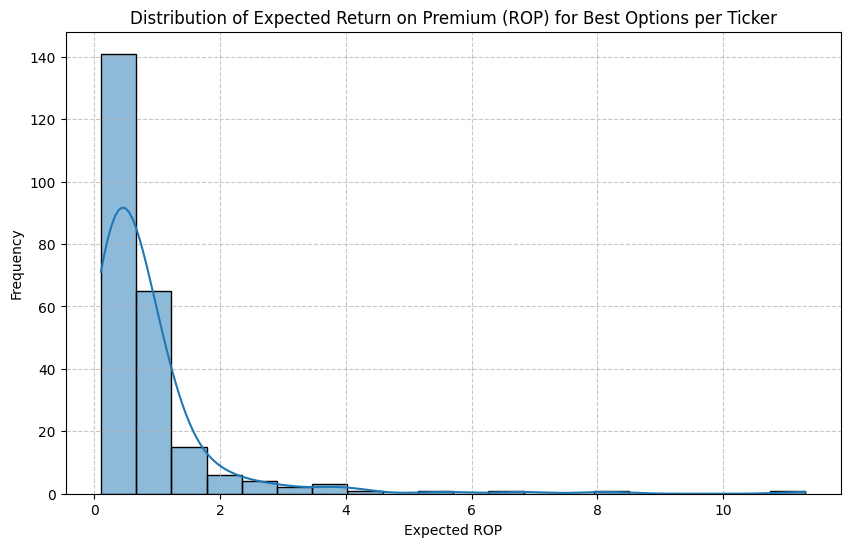

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Expected ROP
plt.figure(figsize=(10, 6))
sns.histplot(best_per_ticker['Expected_ROP'], bins=20, kde=True)
plt.title('Distribution of Expected Return on Premium (ROP) for Best Options per Ticker')
plt.xlabel('Expected ROP')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

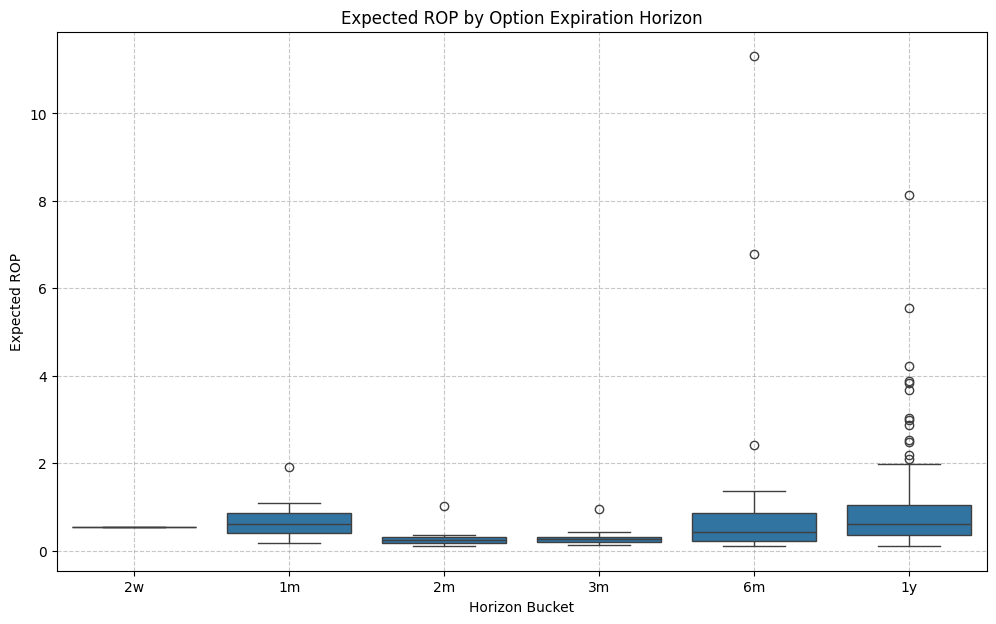

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Expected ROP by Horizon Bucket
plt.figure(figsize=(12, 7))
sns.boxplot(x='Horizon_Bucket', y='Expected_ROP', data=best_per_ticker.sort_values('Days_To_Exp'))
plt.title('Expected ROP by Option Expiration Horizon')
plt.xlabel('Horizon Bucket')
plt.ylabel('Expected ROP')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

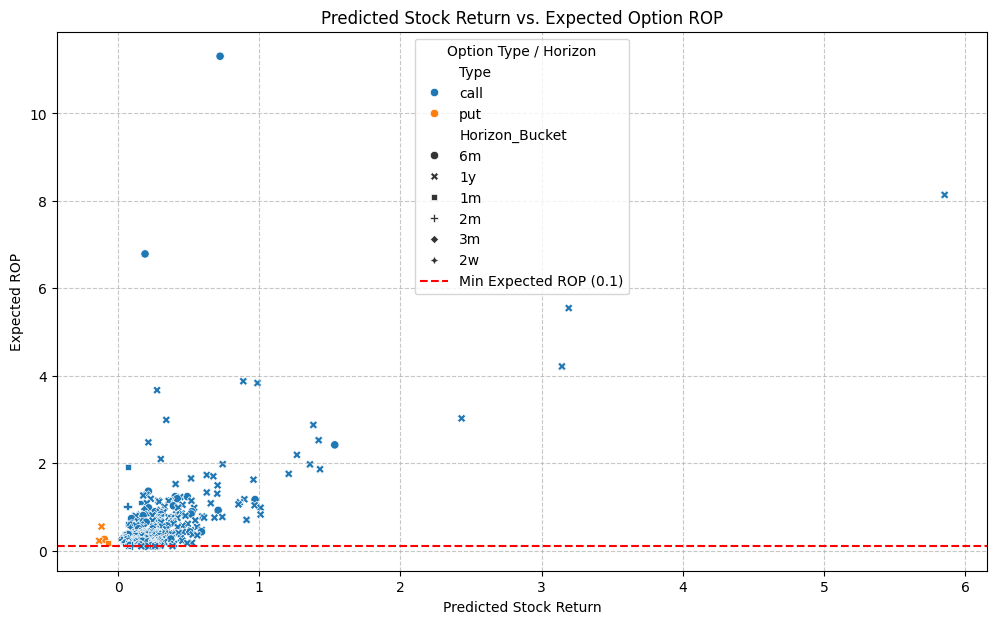

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Predicted Return vs. Expected ROP
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Predicted_Return', y='Expected_ROP', hue='Type', style='Horizon_Bucket', data=best_per_ticker)
plt.title('Predicted Stock Return vs. Expected Option ROP')
plt.xlabel('Predicted Stock Return')
plt.ylabel('Expected ROP')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0.1, color='r', linestyle='--', label='Min Expected ROP (0.1)')
plt.legend(title='Option Type / Horizon')
plt.show()

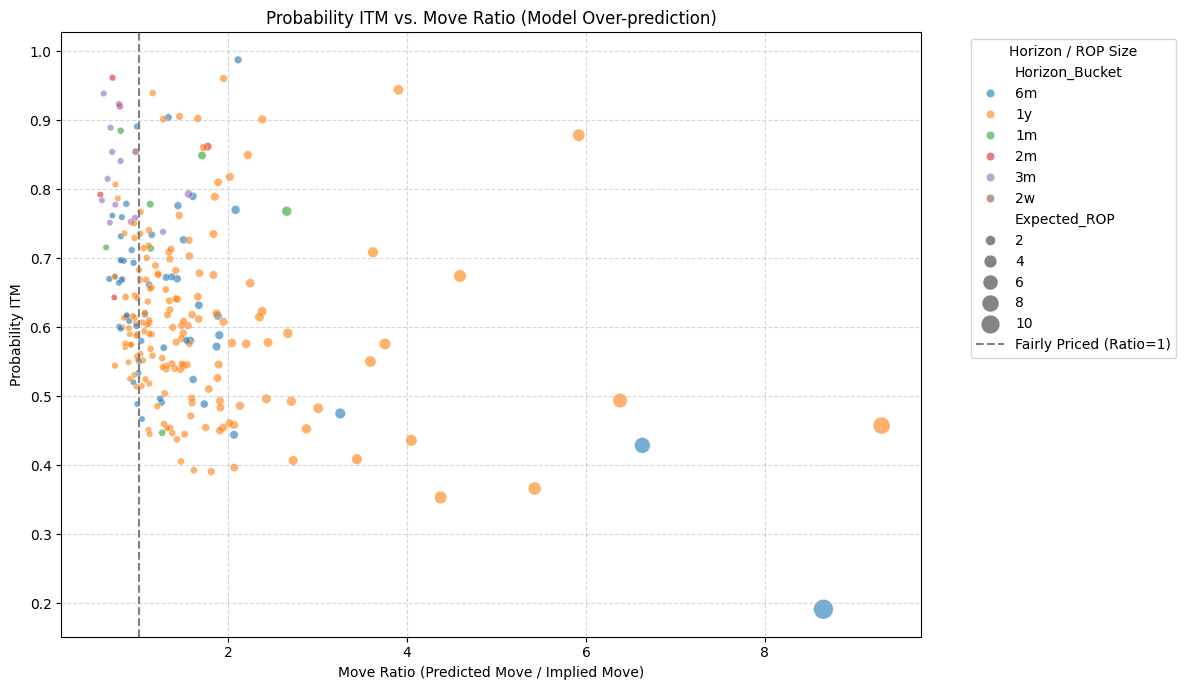

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Prob_ITM vs. Move_Ratio
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Move_Ratio',
    y='Prob_ITM',
    hue='Horizon_Bucket',
    size='Expected_ROP',
    sizes=(20, 200),
    alpha=0.6,
    data=best_per_ticker
)

plt.title('Probability ITM vs. Move Ratio (Model Over-prediction)')
plt.xlabel('Move Ratio (Predicted Move / Implied Move)')
plt.ylabel('Probability ITM')
plt.axvline(1.0, color='gray', linestyle='--', label='Fairly Priced (Ratio=1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Horizon / ROP Size')
plt.tight_layout()
plt.show()

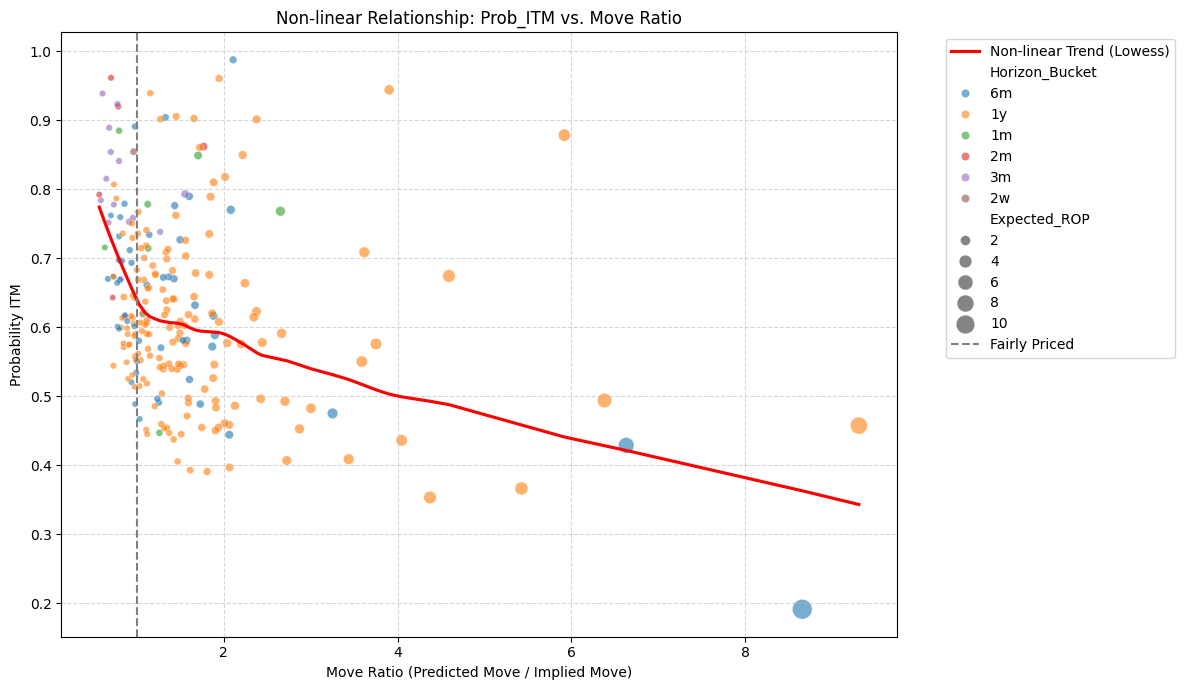

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# Using regplot with lowess=True for the non-linear trend line
sns.regplot(
    x='Move_Ratio',
    y='Prob_ITM',
    data=best_per_ticker,
    scatter=False,
    lowess=True,
    color='red',
    label='Non-linear Trend (Lowess)'
)

# Overlaying the scatter points
sns.scatterplot(
    x='Move_Ratio',
    y='Prob_ITM',
    hue='Horizon_Bucket',
    size='Expected_ROP',
    sizes=(20, 200),
    alpha=0.6,
    data=best_per_ticker
)

plt.title('Non-linear Relationship: Prob_ITM vs. Move Ratio')
plt.xlabel('Move Ratio (Predicted Move / Implied Move)')
plt.ylabel('Probability ITM')
plt.axvline(1.0, color='gray', linestyle='--', label='Fairly Priced')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

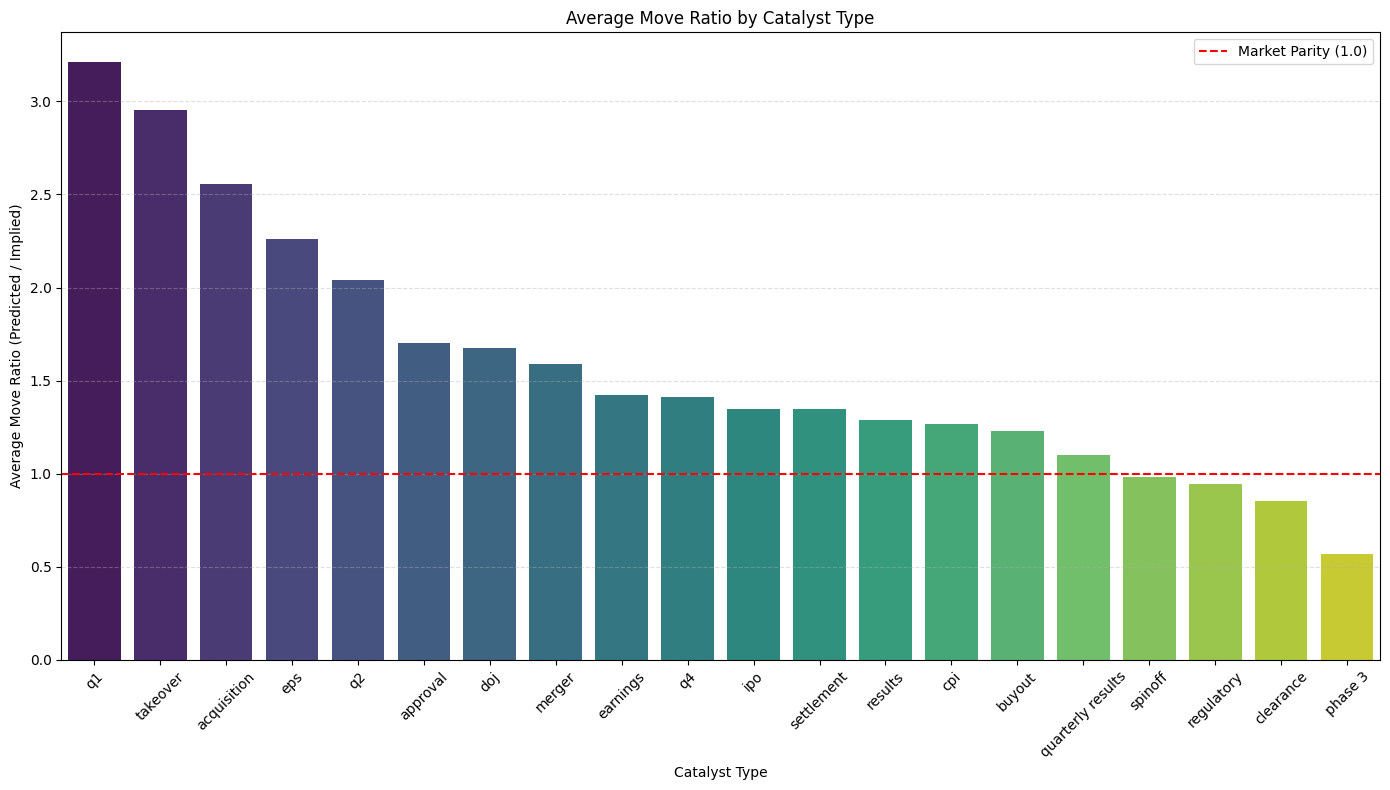

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for rows with catalysts
catalyst_data = best_per_ticker[best_per_ticker['Has_Catalyst'] == True]

# Group by Catalyst_Type and calculate the mean Move_Ratio
avg_move_ratio = catalyst_data.groupby('Catalyst_Type')['Move_Ratio'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))

# Create a bar plot for averages
sns.barplot(
    x='Catalyst_Type',
    y='Move_Ratio',
    data=avg_move_ratio,
    palette='viridis'
)

plt.title('Average Move Ratio by Catalyst Type')
plt.xlabel('Catalyst Type')
plt.ylabel('Average Move Ratio (Predicted / Implied)')
plt.xticks(rotation=45)
plt.axhline(1.0, color='red', linestyle='--', label='Market Parity (1.0)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

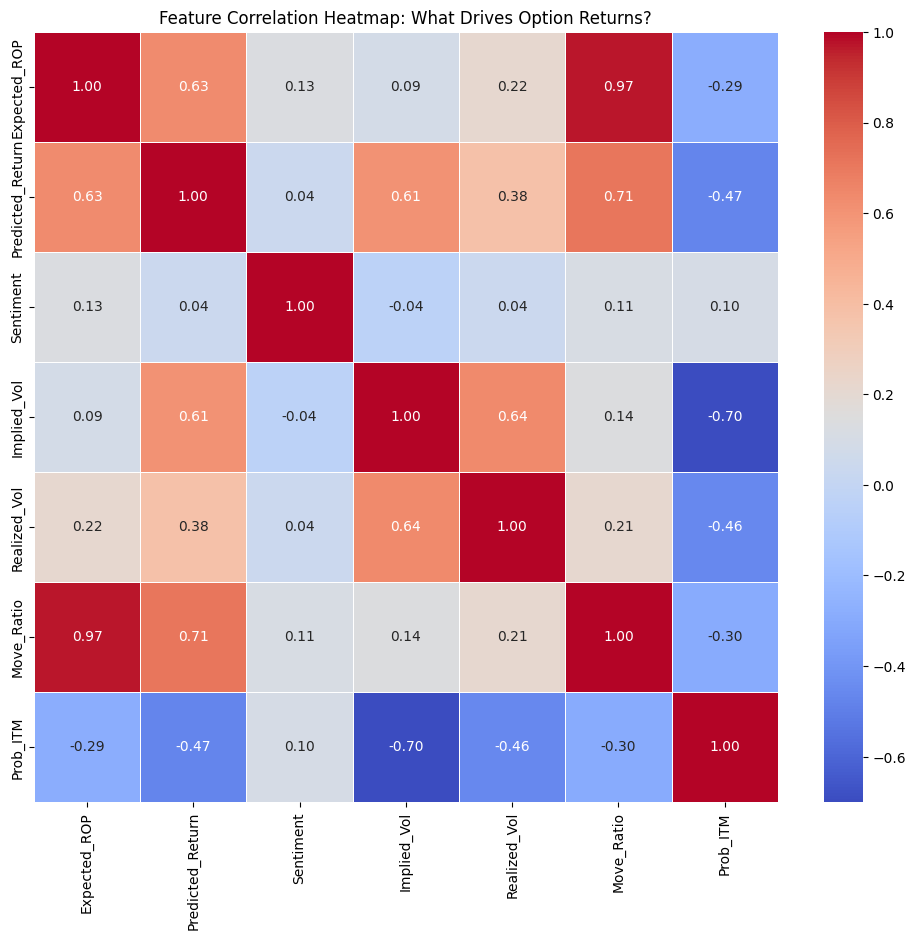

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Correlation Heatmap
plt.figure(figsize=(12, 10))
cols_to_corr = ['Expected_ROP', 'Predicted_Return', 'Sentiment', 'Implied_Vol', 'Realized_Vol', 'Move_Ratio', 'Prob_ITM']
corr_matrix = best_per_ticker[cols_to_corr].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap: What Drives Option Returns?')
plt.show()

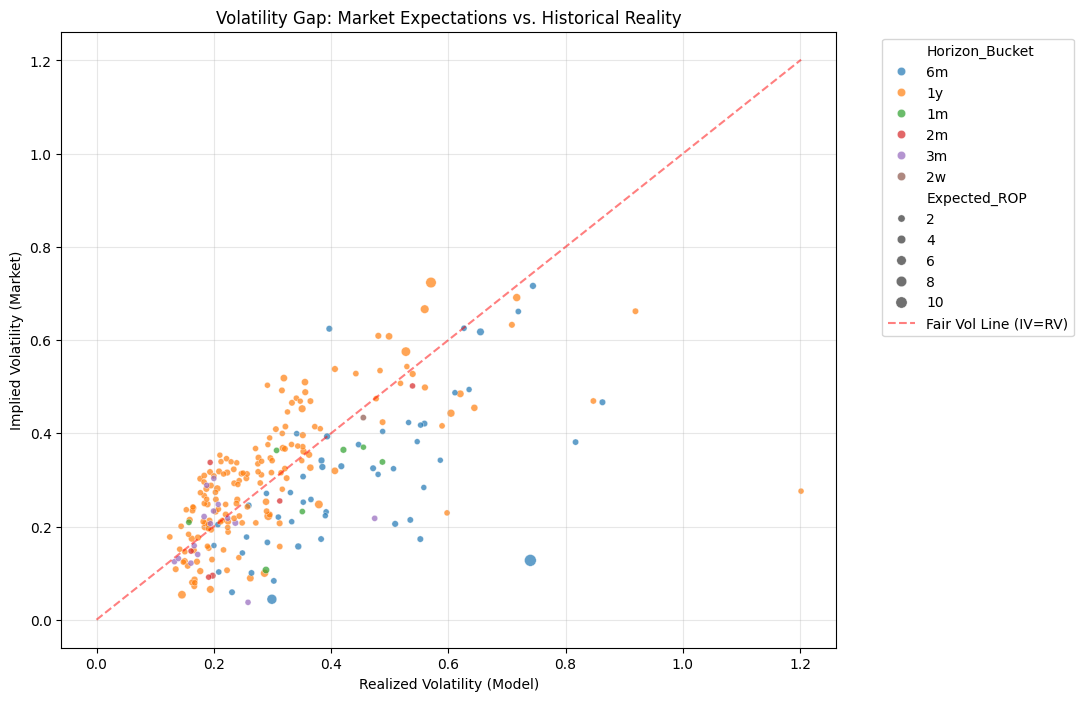

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 6. Implied Vol vs. Realized Vol (The Volatility Gap)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Realized_Vol',
    y='Implied_Vol',
    hue='Horizon_Bucket',
    size='Expected_ROP',
    alpha=0.7,
    data=best_per_ticker
)

# Add a 45-degree line
lims = [0, max(best_per_ticker['Realized_Vol'].max(), best_per_ticker['Implied_Vol'].max())]
plt.plot(lims, lims, 'r--', alpha=0.5, label='Fair Vol Line (IV=RV)')

plt.title('Volatility Gap: Market Expectations vs. Historical Reality')
plt.xlabel('Realized Volatility (Model)')
plt.ylabel('Implied Volatility (Market)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

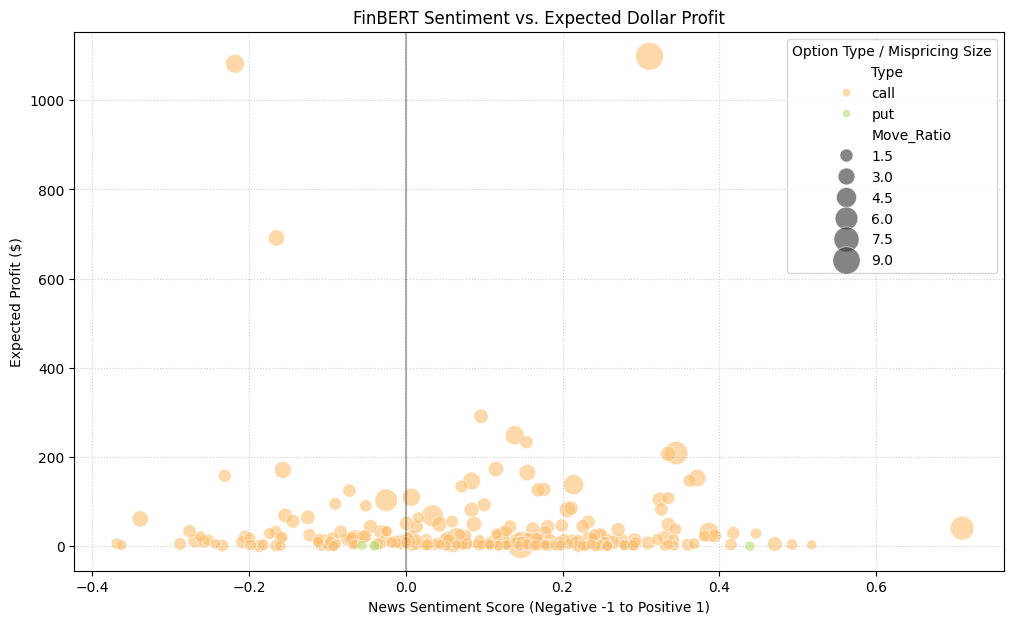

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7. Sentiment Score vs. Expected Profit
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Sentiment',
    y='Expected_Profit',
    hue='Type',
    size='Move_Ratio',
    sizes=(50, 400),
    alpha=0.6,
    palette='RdYlGn',
    data=best_per_ticker
)

plt.title('FinBERT Sentiment vs. Expected Dollar Profit')
plt.xlabel('News Sentiment Score (Negative -1 to Positive 1)')
plt.ylabel('Expected Profit ($)')
plt.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Option Type / Mispricing Size')
plt.show()

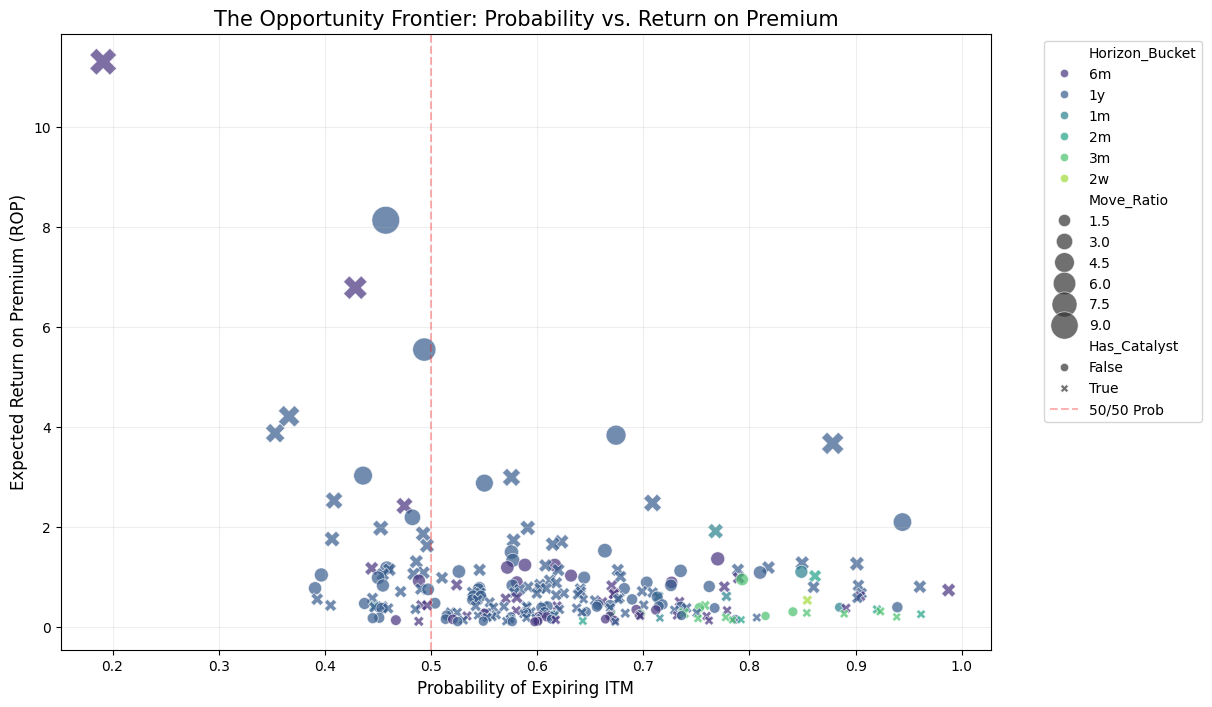

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 8. The Opportunity Frontier: High Prob vs High Return
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Prob_ITM',
    y='Expected_ROP',
    hue='Horizon_Bucket',
    style='Has_Catalyst',
    size='Move_Ratio',
    sizes=(40, 400),
    alpha=0.7,
    palette='viridis',
    data=best_per_ticker
)

plt.title('The Opportunity Frontier: Probability vs. Return on Premium', fontsize=15)
plt.xlabel('Probability of Expiring ITM', fontsize=12)
plt.ylabel('Expected Return on Premium (ROP)', fontsize=12)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.3, label='50/50 Prob')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

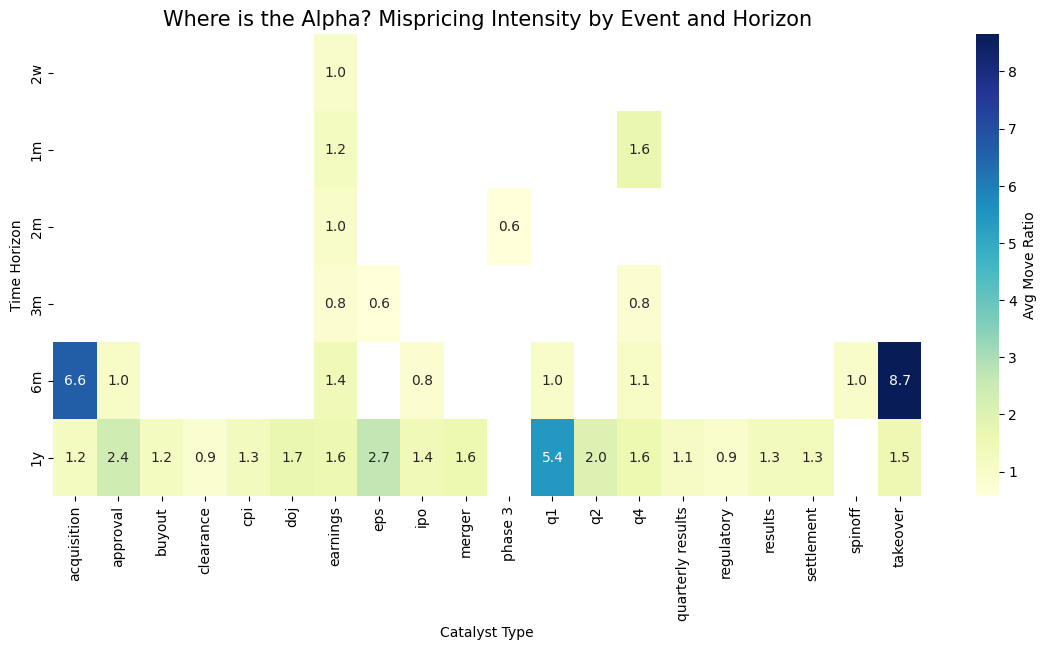

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 9. Mispricing Intensity Heatmap (Catalyst vs. Horizon)
# This shows which event-time combos are most inefficient
pivot_df = best_per_ticker[best_per_ticker['Has_Catalyst']].groupby(['Horizon_Bucket', 'Catalyst_Type'])['Move_Ratio'].mean().unstack()
# Reorder horizons logically
h_order = ['1w', '2w', '1m', '2m', '3m', '6m', '1y']
pivot_df = pivot_df.reindex([h for h in h_order if h in pivot_df.index])

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt='.1f', cbar_kws={'label': 'Avg Move Ratio'})
plt.title('Where is the Alpha? Mispricing Intensity by Event and Horizon', fontsize=15)
plt.xlabel('Catalyst Type')
plt.ylabel('Time Horizon')
plt.show()

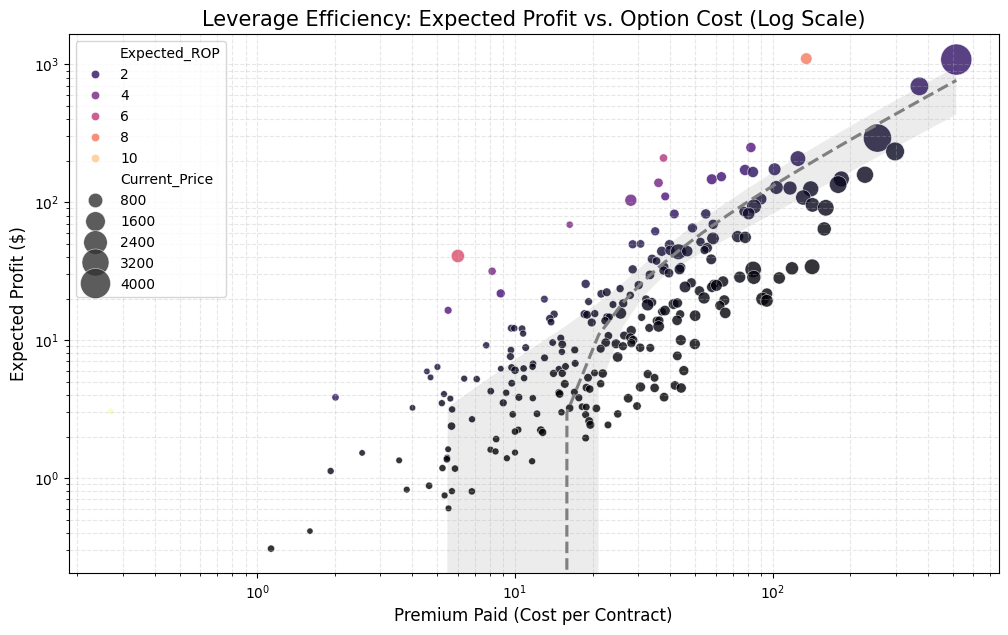

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 10. Leverage Efficiency: Profit vs. Cost
plt.figure(figsize=(12, 7))
best_per_ticker['Profit_Per_Dollar'] = best_per_ticker['Expected_Profit'] / best_per_ticker['Premium']

sns.regplot(
    x='Premium',
    y='Expected_Profit',
    data=best_per_ticker,
    scatter=False,
    color='gray',
    line_kws={'linestyle':'--'}
)

sns.scatterplot(
    x='Premium',
    y='Expected_Profit',
    hue='Expected_ROP',
    size='Current_Price',
    sizes=(20, 500),
    palette='magma',
    alpha=0.8,
    data=best_per_ticker
)

plt.xscale('log')
plt.yscale('log')
plt.title('Leverage Efficiency: Expected Profit vs. Option Cost (Log Scale)', fontsize=15)
plt.xlabel('Premium Paid (Cost per Contract)', fontsize=12)
plt.ylabel('Expected Profit ($)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()

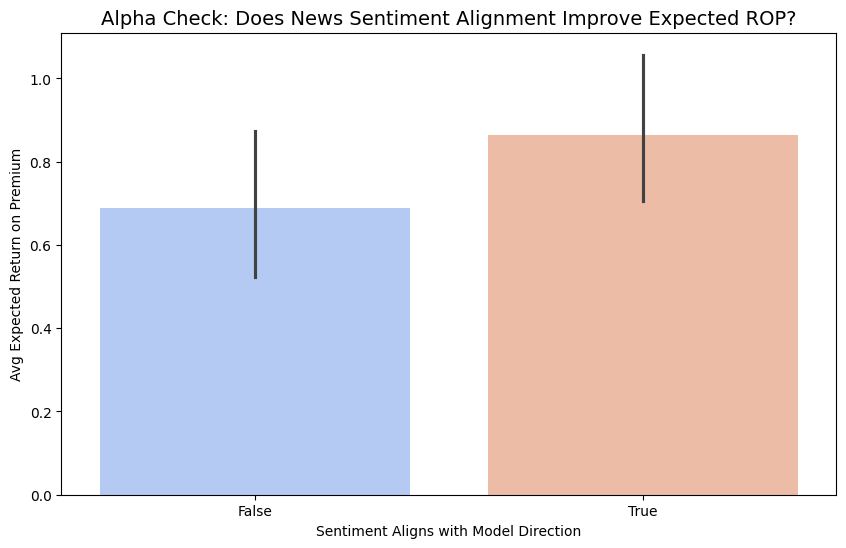

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 11. ROI for Sentiment-Aligned vs. Conflicting Trades
plt.figure(figsize=(10, 6))
sns.barplot(x='Sent_Aligned', y='Expected_ROP', data=best_per_ticker, palette='coolwarm')
plt.title('Alpha Check: Does News Sentiment Alignment Improve Expected ROP?', fontsize=14)
plt.ylabel('Avg Expected Return on Premium')
plt.xlabel('Sentiment Aligns with Model Direction')
plt.show()

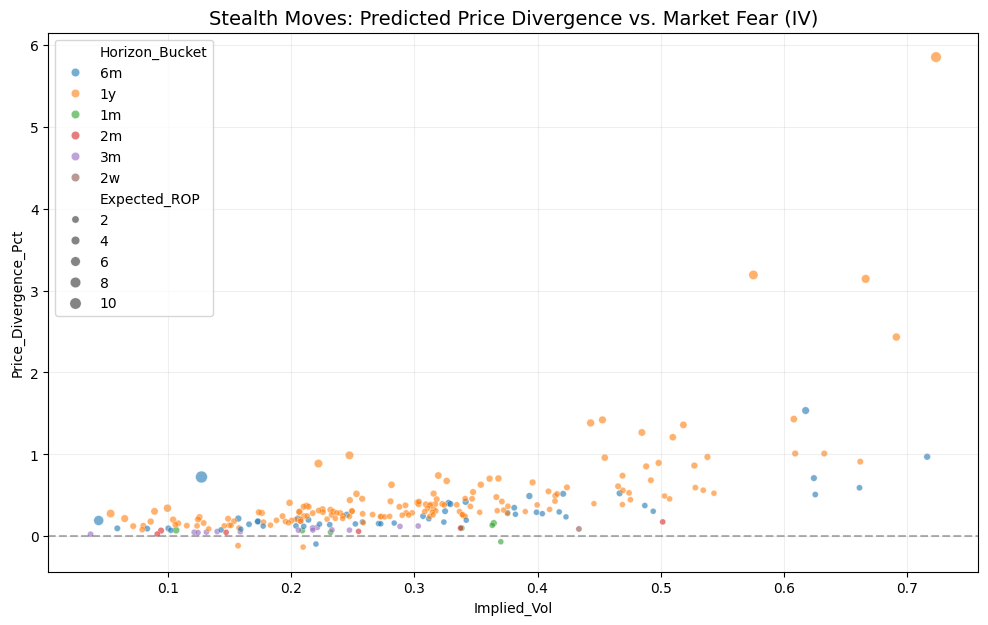

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 12. Divergence vs. Implied Volatility
best_per_ticker['Price_Divergence_Pct'] = (best_per_ticker['Predicted_Price'] - best_per_ticker['Current_Price']) / best_per_ticker['Current_Price']

plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Implied_Vol',
    y='Price_Divergence_Pct',
    hue='Horizon_Bucket',
    size='Expected_ROP',
    alpha=0.6,
    data=best_per_ticker
)
plt.title('Stealth Moves: Predicted Price Divergence vs. Market Fear (IV)', fontsize=14)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 13. ROP vs. Beta (Systemic Risk Check)
# Added check to prevent KeyError if Beta hasn't been calculated in the current dataset
if 'beta_60' in best_per_ticker.columns:
    plt.figure(figsize=(12, 7))
    sns.regplot(x='beta_60', y='Expected_ROP', data=best_per_ticker, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title('Beta Sensitivity: Are we just riding Market Volatility?', fontsize=14)
    plt.xlabel('60-Day Stock Beta (Systemic Risk)')
    plt.ylabel('Expected Return on Premium')
    plt.show()
else:
    print("Column 'beta_60' not found in the current dataset.")
    print("Please re-run the full screening script to include Beta calculations.")

Column 'beta_60' not found in the current dataset.
Please re-run the full screening script to include Beta calculations.


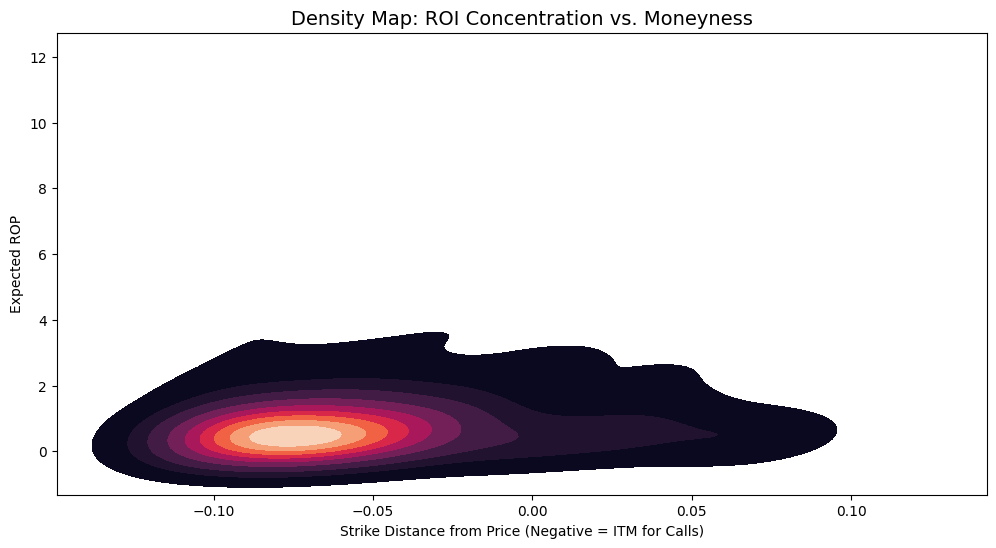

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 14. Where is the ROI? (Deltas/Moneyness Heatmap)
# We'll approximate 'Moneyness' by the distance between Strike and Price
best_per_ticker['Moneyness'] = (best_per_ticker['Strike'] / best_per_ticker['Current_Price']) - 1

plt.figure(figsize=(12, 6))
sns.kdeplot(data=best_per_ticker, x='Moneyness', y='Expected_ROP', fill=True, cmap='rocket')
plt.title('Density Map: ROI Concentration vs. Moneyness', fontsize=14)
plt.xlabel('Strike Distance from Price (Negative = ITM for Calls)')
plt.ylabel('Expected ROP')
plt.show()

In [ ]:
import plotly.express as px

# Interactive Opportunity Frontier
fig1 = px.scatter(
    best_per_ticker,
    x='Prob_ITM',
    y='Expected_ROP',
    color='Horizon_Bucket',
    size='Move_Ratio',
    hover_data=['Ticker', 'Type', 'Expiration', 'Strike', 'Current_Price', 'Predicted_Price'],
    title='Interactive Opportunity Frontier: Hover to Explore Trades',
    labels={'Prob_ITM': 'Probability ITM', 'Expected_ROP': 'Expected Return on Premium'}
)

fig1.update_layout(template='plotly_white')
fig1.show()

In [ ]:
import plotly.express as px

# Interactive Master Map (Risk vs. Value)
fig2 = px.scatter(
    best_per_ticker,
    x='Premium',
    y='Expected_Profit',
    color='Prob_ITM',
    size='Move_Ratio',
    log_x=True,
    log_y=True,
    hover_data=['Ticker', 'Type', 'Expiration', 'Strike', 'Expected_ROP'],
    title='Interactive Master Map: Profit vs. Capital at Risk',
    labels={'Premium': 'Cost (Premium Paid)', 'Expected_Profit': 'Expected Profit ($)'},
    color_continuous_scale='Viridis'
)

fig2.update_layout(template='plotly_white')
fig2.show()

In [ ]:
import plotly.express as px

# Thesis 1: Event-Driven Alpha
# Shows which Catalyst Types offer the highest ROI per unit of ITM Probability
fig_cat = px.scatter(
    best_per_ticker[best_per_ticker['Has_Catalyst']],
    x='Prob_ITM',
    y='Expected_ROP',
    color='Catalyst_Type',
    size='Move_Ratio',
    hover_data=['Ticker', 'Expiration', 'Predicted_Return'],
    title='Investment Thesis: Catalyst Alpha (ROI vs Probability per Event Type)',
    labels={'Prob_ITM': 'Probability of Success', 'Expected_ROP': 'Expected ROI'}
)
fig_cat.update_layout(template='plotly_white')
fig_cat.show()

In [ ]:
import plotly.express as px

# Thesis 2: Stealth Volatility
# Finding high Predicted Moves with low Implied Volatility (The 'Stealth' setup)
fig_stealth = px.scatter(
    best_per_ticker,
    x='Implied_Vol',
    y='Predicted_Return',
    color='Expected_ROP',
    size='Move_Ratio',
    hover_data=['Ticker', 'Strike', 'Days_To_Exp'],
    title='Investment Thesis: Stealth Moves (High Prediction vs Low Market IV)',
    labels={'Implied_Vol': 'Market Fear (IV)', 'Predicted_Return': 'Model Predicted Return'},
    color_continuous_scale='RdYlGn'
)
fig_stealth.update_layout(template='plotly_white')
fig_stealth.show()

In [ ]:
import plotly.express as px

# Thesis 3: Time-Horizon Efficiency
# Visualizing where the ROP 'Sweet Spot' lies in terms of time to expiration
fig_time = px.box(
    best_per_ticker,
    x='Horizon_Bucket',
    y='Expected_ROP',
    color='Type',
    points='all',
    hover_data=['Ticker', 'Days_To_Exp'],
    title='Investment Thesis: Horizon Efficiency (Where is the ROI concentrated?)',
    category_orders={'Horizon_Bucket': ['1w', '2w', '1m', '2m', '3m', '6m', '1y']}
)
fig_time.update_layout(template='plotly_white')
fig_time.show()

In [ ]:
import plotly.express as px

# Thesis 4: Leverage vs. Safety
# Visualizing Predicted Move (Magnitude) vs Probability of Success (ITM)
fig_move_prob = px.scatter(
    best_per_ticker,
    x='Prob_ITM',
    y='Predicted_Move',
    color='Horizon_Bucket',
    size='Expected_ROP',
    hover_data=['Ticker', 'Type', 'Strike', 'Current_Price', 'Predicted_Price'],
    title='Investment Thesis: Predicted Move Magnitude vs. Probability ITM',
    labels={'Prob_ITM': 'Probability of Success (ITM)', 'Predicted_Move': 'Predicted Move Magnitude ($)'},
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig_move_prob.update_layout(template='plotly_white')
fig_move_prob.show()

In [ ]:
import pandas as pd
import numpy as np

# Calculate the percentage divergence for all rows
df['divergence_pct'] = (df['Predicted_Price'] - df['Current_Price']) / df['Current_Price']

# Calculate mean and standard deviation of the divergence
mean_div = df['divergence_pct'].mean()
std_div = df['divergence_pct'].std()

# Define bounds (2 Standard Deviations)
lower_bound = mean_div - 2 * std_div
upper_bound = mean_div + 2 * std_div

# Create the filtered dataframe
df_filtered = df[(df['divergence_pct'] >= lower_bound) & (df['divergence_pct'] <= upper_bound)].copy()

# Update best_per_ticker using the filtered data
best_per_ticker_filtered = (
    df_filtered.sort_values("Expected_ROP", ascending=False)
    .groupby("Ticker")
    .first()
    .reset_index()
    .sort_values("Expected_ROP", ascending=False)
)

print(f"Original rows: {len(df)}")
print(f"Filtered rows: {len(df_filtered)}")
print(f"Removed {len(df) - len(df_filtered)} outlier option contracts.")
print(f"Divergence Bounds (2 SD): {lower_bound:.2%} to {upper_bound:.2%}")

display(best_per_ticker_filtered.head(10))

Original rows: 2675
Filtered rows: 2627
Removed 48 outlier option contracts.
Divergence Bounds (2 SD): -69.29% to 172.32%


,Ticker,Type,Expiration,Days_To_Exp,Horizon_Bucket,Current_Price,Predicted_Price,Predicted_Return,Strike,Premium,...,Has_Catalyst,Catalyst_Type,Headlines,Has_Earnings,Avg_Earnings_Move,Signal_Score,Prob_ITM,Expected_Profit,Expected_ROP,divergence_pct
229,WBD,call,2026-08-21,157,6m,27.51,47.39,0.7225,30.0,0.27,...,True,takeover,10,False,0.0,1.2794,0.1912,3.0537,11.3101,0.722646
206,TDY,call,2026-08-21,157,6m,645.66,768.99,0.1910,660.0,6.00,...,True,acquisition,10,False,0.0,1.3920,0.4287,40.7260,6.7877,0.191014
213,TPR,call,2027-01-15,304,1y,141.78,267.51,0.8868,155.0,8.15,...,True,q2,10,False,0.0,1.2021,0.3532,31.5881,3.8758,0.886796
118,HWM,call,2026-12-18,276,1y,240.73,478.45,0.9875,220.0,36.04,...,False,None,10,False,0.0,1.0610,0.6743,138.2274,3.8354,0.987496
138,LIN,call,2026-12-18,276,1y,497.41,634.68,0.2760,485.0,28.15,...,True,eps,10,False,0.0,1.2549,0.8784,103.3377,3.6710,0.275970
177,PCAR,call,2027-01-15,304,1y,115.63,155.12,0.3415,117.0,5.50,...,True,earnings,10,False,0.0,1.0137,0.5758,16.4502,2.9909,0.341520
170,NVDA,call,2026-12-18,276,1y,183.22,436.64,1.3831,167.0,38.28,...,False,None,10,False,0.0,0.8195,0.5503,110.1062,2.8763,1.383146
41,CIEN,call,2027-01-15,304,1y,363.88,880.80,1.4206,380.0,58.03,...,True,earnings,10,False,0.0,0.9546,0.4087,146.6567,2.5273,1.420578
73,EA,call,2027-01-15,304,1y,200.21,243.19,0.2147,200.0,8.80,...,True,earnings,10,False,0.0,0.9867,0.7087,21.8078,2.4782,0.214675
230,WDC,call,2026-10-16,213,6m,286.21,725.43,1.5346,270.0,63.25,...,True,earnings,10,False,0.0,0.9750,0.4750,153.0591,2.4199,1.534607


In [ ]:
import plotly.express as px

# Filtered Interactive Opportunity Frontier
fig_f1 = px.scatter(
    best_per_ticker_filtered,
    x='Prob_ITM',
    y='Expected_ROP',
    color='Horizon_Bucket',
    size='Move_Ratio',
    hover_data=['Ticker', 'Type', 'Expiration', 'Strike', 'Current_Price', 'Predicted_Price'],
    title='Filtered Opportunity Frontier (Outliers Removed)',
    labels={'Prob_ITM': 'Probability ITM', 'Expected_ROP': 'Expected Return on Premium'}
)

fig_f1.update_layout(template='plotly_white')
fig_f1.show()

In [ ]:
import plotly.express as px

# Filtered Interactive Master Map
fig_f2 = px.scatter(
    best_per_ticker_filtered,
    x='Premium',
    y='Expected_Profit',
    color='Prob_ITM',
    size='Move_Ratio',
    log_x=True,
    log_y=True,
    hover_data=['Ticker', 'Type', 'Expiration', 'Strike', 'Expected_ROP'],
    title='Filtered Master Map (Profit vs. Capital at Risk)',
    labels={'Premium': 'Cost (Premium Paid)', 'Expected_Profit': 'Expected Profit ($)'},
    color_continuous_scale='Viridis'
)

fig_f2.update_layout(template='plotly_white')
fig_f2.show()

In [ ]:
import plotly.express as px

# Filtered Stealth Moves Thesis
fig_f3 = px.scatter(
    best_per_ticker_filtered,
    x='Implied_Vol',
    y='Predicted_Return',
    color='Expected_ROP',
    size='Move_Ratio',
    hover_data=['Ticker', 'Strike', 'Days_To_Exp'],
    title='Filtered Investment Thesis: Stealth Moves',
    labels={'Implied_Vol': 'Market Fear (IV)', 'Predicted_Return': 'Model Predicted Return'},
    color_continuous_scale='RdYlGn'
)
fig_f3.update_layout(template='plotly_white')
fig_f3.show()

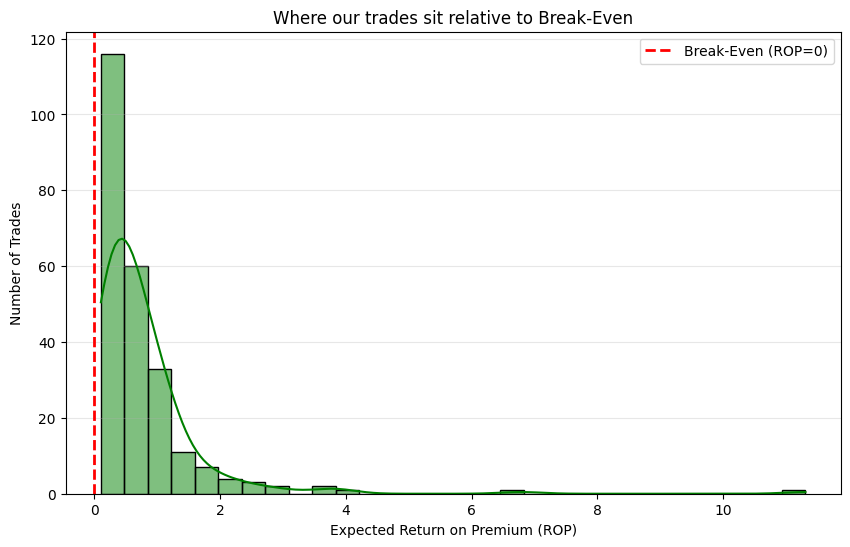

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the profit threshold
plt.figure(figsize=(10, 6))
sns.histplot(best_per_ticker_filtered['Expected_ROP'], bins=30, color='green', kde=True)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Break-Even (ROP=0)')
plt.title('Where our trades sit relative to Break-Even')
plt.xlabel('Expected Return on Premium (ROP)')
plt.ylabel('Number of Trades')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
import plotly.express as px

# Calculate Premium as a proportion of Current Price
best_per_ticker_filtered['Premium_Pct_of_Price'] = best_per_ticker_filtered['Premium'] / best_per_ticker_filtered['Current_Price']

fig_prop = px.scatter(
    best_per_ticker_filtered,
    x='Premium_Pct_of_Price',
    y='Prob_ITM',
    color='Horizon_Bucket',
    size='Expected_ROP',
    hover_data=['Ticker', 'Strike', 'Premium', 'Current_Price', 'Predicted_Price', 'Expected_Profit'],
    title='Entry Cost Efficiency: Premium/Price vs. Prob ITM',
    labels={
        'Premium_Pct_of_Price': 'Cost of Entry (Premium / Stock Price)',
        'Prob_ITM': 'Probability ITM'
    }
)

fig_prop.update_layout(template='plotly_white')
fig_prop.show()

In [6]:
import google, json, nbformat
import os
import time

# Get the current notebook
raw_notebook = google.colab._message.blocking_request("get_ipynb",
                                                      timeout_sec=30)["ipynb"]

# Clear all cell outputs before saving to avoid issues with nbconvert processing widget states
for cell in raw_notebook['cells']:
    if 'outputs' in cell:
        cell['outputs'] = []
    if 'metadata' in cell and 'output_stream' in cell['metadata']:
        del cell['metadata']['output_stream']

# Write the cleared notebook to _NOTEBOOK.ipynb
with open("_NOTEBOOK.ipynb", "w", encoding="utf-8") as ipynb_file:
  ipynb_file.write(json.dumps(raw_notebook))

# Use nbconvert to convert .ipynb to .html with a basic template.
!jupyter nbconvert --to html --template basic --log-level WARN _NOTEBOOK.ipynb

# Add a small delay to ensure the file system has caught up
time.sleep(2)

# Download the .html file.
if os.path.exists("_NOTEBOOK.html"):
  google.colab.files.download("_NOTEBOOK.html")
else:
  print("Error: _NOTEBOOK.html was not created by nbconvert.")
  print("Please check the output of the nbconvert command above for more details.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
!pip install --upgrade nbconvert jupyter_core